Jupyter Notebook to extract closure quantities from Basilisk C DNS. 

There are two types of files.

    1. snapshot_XXXXX.h5 files which contain u,p,f,d data at t and t-dt along with parameters. 
    2. interface and interface_minus files which contain PLIC reconstructed interface data and curvatures at t and t-dt respectively.
The objective is to extract relevant closure quantities and spatial derivatives of thin-film equation terms from the DNS data.

In [1]:
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.axes import Axes
from matplotlib.figure import Figure

from __future__ import annotations

import argparse
from collections.abc import Iterable
from dataclasses import dataclass
from pathlib import Path

HDF5 dataset loading functions

     1. load_h5 - Accepts a complete hdf5 file path of a directory and filename. Recursively loads every dataset into a dictionary whose keys are complete HDF5 paths. 
     2. inspect_h5 - Takes file path and prints all groups, datsets, dataset shapes, data types and root attributes.
     3. 

In [2]:
def load_h5(filepath: str | Path, filename: str) -> dict[str, np.ndarray]:
    """
    Load all datasets from an HDF5 file.

    Parameters
    ----------
    filepath
        Directory containing the HDF5 file.

    filename
        Name of the HDF5 file, including the .h5 extension.

    Returns
    -------
    dict[str, np.ndarray]
        Dictionary containing all HDF5 datasets.

        The dictionary keys are the full dataset paths inside the
        HDF5 file. The values are NumPy arrays.

    Raises
    ------
    FileNotFoundError
        If the requested HDF5 file does not exist.

    OSError
        If the file exists but cannot be opened as an HDF5 file.
    """
    full_path = Path(filepath) / filename

    if not full_path.is_file():
        raise FileNotFoundError(
            f"HDF5 file was not found: {full_path.resolve()}"
        )

    data: dict[str, np.ndarray] = {}

    with h5py.File(full_path, mode="r") as h5_file:

        def load_dataset(name: str, obj: h5py.Dataset | h5py.Group) -> None:
            if isinstance(obj, h5py.Dataset):
                data[name] = obj[...]

        h5_file.visititems(load_dataset)

    return data

In [3]:
def compute_cell_centers(
    points: np.ndarray,
    topology: np.ndarray,
) -> np.ndarray:
    """
    Compute cell-center coordinates from mesh vertices and topology.

    Parameters
    ----------
    points
        Vertex coordinates with shape (n_points, n_dimensions).

    topology
        Cell connectivity with shape (n_cells, n_vertices_per_cell).
        Each row contains the vertex indices belonging to one cell.

    Returns
    -------
    np.ndarray
        Cell-center coordinates with shape (n_cells, n_dimensions).
    """
    points = np.asarray(points)
    topology = np.asarray(topology, dtype=np.int64)

    # Coordinates of every vertex belonging to every cell.
    # Shape:
    # (n_cells, n_vertices_per_cell, n_dimensions)
    cell_vertices = points[topology]

    # Average the vertex coordinates for each cell.
    cell_centers = cell_vertices.mean(axis=1)

    return cell_centers

In [4]:
def build_cartesian_cell_grid(
    cell_centers: np.ndarray,
    decimals: int = 12,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Build Cartesian cell-center coordinate matrices.

    Parameters
    ----------
    cell_centers
        Cell-center coordinates with shape (n_cells, 2) or
        (n_cells, 3).

    decimals
        Number of decimal places used when identifying unique
        coordinates. This prevents floating-point roundoff from
        creating duplicate coordinate values.

    Returns
    -------
    x_matrix
        Cell-center x coordinates with shape (ny, nx).

    y_matrix
        Cell-center y coordinates with shape (ny, nx).

    sorting_indices
        Indices that reorder cell-based fields into matrix order.
    """
    cell_centers = np.asarray(cell_centers)

    x = cell_centers[:, 0]
    y = cell_centers[:, 1]

    x_rounded = np.round(x, decimals=decimals)
    y_rounded = np.round(y, decimals=decimals)

    unique_x = np.unique(x_rounded)
    unique_y = np.unique(y_rounded)

    nx = len(unique_x)
    ny = len(unique_y)

    if nx * ny != len(cell_centers):
        raise ValueError(
            "The cell centers do not form a complete Cartesian grid. "
            f"Found nx={nx}, ny={ny}, but nx*ny={nx * ny} and "
            f"n_cells={len(cell_centers)}."
        )

    # Primary sorting key: y
    # Secondary sorting key: x
    sorting_indices = np.lexsort((x_rounded, y_rounded))

    x_sorted = x[sorting_indices]
    y_sorted = y[sorting_indices]

    x_matrix = x_sorted.reshape(ny, nx)
    y_matrix = y_sorted.reshape(ny, nx)

    return x_matrix, y_matrix, sorting_indices

In [5]:
def vector_to_matrices(
    vector: np.ndarray,
    sorting_indices: np.ndarray,
    matrix_shape: tuple[int, int],
) -> tuple[np.ndarray, ...]:
    """
    Convert a cell-based vector field into component matrices.

    Parameters
    ----------
    vector
        Vector field with shape (n_cells, n_components).

    sorting_indices
        Sorting indices returned by build_cartesian_cell_grid().

    matrix_shape
        Desired matrix shape, normally x_matrix.shape.

    Returns
    -------
    tuple[np.ndarray, ...]
        One matrix for each vector component.
    """
    vector = np.asarray(vector)

    if vector.ndim != 2:
        raise ValueError(
            f"Expected vector shape (n_cells, n_components), "
            f"but received {vector.shape}."
        )

    if vector.shape[0] != len(sorting_indices):
        raise ValueError(
            f"Vector contains {vector.shape[0]} cells, but the mesh contains "
            f"{len(sorting_indices)} cells."
        )

    vector_sorted = vector[sorting_indices]

    return tuple(
        vector_sorted[:, component].reshape(matrix_shape)
        for component in range(vector.shape[1])
    )

In [6]:
def scalar_to_matrix(
    scalar: np.ndarray,
    sorting_indices: np.ndarray,
    matrix_shape: tuple[int, int],
) -> np.ndarray:
    """
    Convert a cell-based scalar field into a 2D Cartesian matrix.

    Parameters
    ----------
    scalar
        Scalar field with one value per cell.

    sorting_indices
        Sorting indices returned by build_cartesian_cell_grid().

    matrix_shape
        Desired matrix shape, normally x_matrix.shape.

    Returns
    -------
    np.ndarray
        Scalar field with shape (ny, nx).
    """
    scalar = np.asarray(scalar).squeeze()

    if scalar.ndim != 1:
        raise ValueError(
            f"Expected a one-dimensional scalar field after squeezing, "
            f"but received shape {scalar.shape}."
        )

    if len(scalar) != len(sorting_indices):
        raise ValueError(
            f"Scalar contains {len(scalar)} values, but the mesh contains "
            f"{len(sorting_indices)} cells."
        )

    return scalar[sorting_indices].reshape(matrix_shape)

The following functions are closure utilities aimed at using the cell-centered data to derive the required quantities.

In [7]:
def depth_integral(
    x: np.ndarray,
    y: np.ndarray,
    field: np.ndarray,
    *,
    lower_boundary: float = 0.0,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Depth-integrate a cell-centered field along y at every x-location.

    Computes

        I(x) = integral field(x, y) dy

    using a finite-volume sum:

        I(x_i) = sum_j field[j, i] * dy[j, i]

    Parameters
    ----------
    x
        Cell-center x-coordinate matrix with shape (ny, nx).

    y
        Cell-center y-coordinate matrix with shape (ny, nx).

    field
        Cell-centered field with shape (ny, nx).

    lower_boundary
        Physical location of the lower boundary. For a wall at y = 0,
        use the default value 0.0.

    Returns
    -------
    x_locations
        One-dimensional array of x locations with shape (nx,).

    integral
        Depth-integrated field at every x location with shape (nx,).
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    field = np.asarray(field, dtype=float)

    if x.ndim != 2 or y.ndim != 2 or field.ndim != 2:
        raise ValueError("x, y, and field must be two-dimensional arrays.")

    if x.shape != y.shape or x.shape != field.shape:
        raise ValueError(
            "x, y, and field must have identical shapes. "
            f"Received x={x.shape}, y={y.shape}, "
            f"field={field.shape}."
        )

    ny, nx = field.shape

    if ny < 2:
        raise ValueError(
            "At least two cells in the y-direction are required "
            "to reconstruct cell boundaries."
        )

    x_locations = x[0, :].copy()
    integral = np.zeros(nx, dtype=float)

    for i in range(nx):
        y_column = y[:, i]
        field_column = field[:, i]

        # Ensure cells are ordered from bottom to top.
        order = np.argsort(y_column)
        y_sorted = y_column[order]
        field_sorted = field_column[order]

        if np.any(np.diff(y_sorted) <= 0.0):
            raise ValueError(
                f"Repeated or non-increasing y coordinates found at "
                f"x-index {i}."
            )

        # Reconstruct cell-face locations from cell centers.
        y_faces = np.empty(ny + 1, dtype=float)

        # Physical lower wall.
        y_faces[0] = lower_boundary

        # Interior faces lie halfway between neighboring cell centers.
        y_faces[1:ny] = 0.5 * (
            y_sorted[:-1] + y_sorted[1:]
        )

        # Extrapolate the upper face by half the final center spacing.
        y_faces[ny] = (
            y_sorted[-1]
            + 0.5 * (y_sorted[-1] - y_sorted[-2])
        )

        cell_heights = np.diff(y_faces)

        if np.any(cell_heights <= 0.0):
            raise ValueError(
                f"Non-positive cell height reconstructed at x-index {i}."
            )

        integral[i] = np.sum(
            field_sorted * cell_heights
        )

    return x_locations, integral

In [8]:
def compute_wall_shear(
    x: np.ndarray,
    y: np.ndarray,
    u: np.ndarray,
    mu: float = 1.0,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Compute lower-wall shear stress from a cell-centered velocity field.

    Assumptions
    -----------
    - Uniform Cartesian mesh.
    - Lower wall is located at y = 0.
    - No-slip condition: u_wall = 0.
    - Cell centers are located at:
          y_j = (j + 1/2) * dy

    Parameters
    ----------
    x, y : ndarray, shape (ny, nx)
        Cell-center coordinates.

    u : ndarray, shape (ny, nx)
        Streamwise velocity.

    mu : float
        Dynamic viscosity.

    order : 4
        Accuracy order of the wall-gradient stencil.

    Returns
    -------
    x_wall : ndarray, shape (nx,)
        Streamwise coordinates along the wall.

    tau_w : ndarray, shape (nx,)
        Wall shear stress:
            tau_w = mu * (du/dy)_wall
    """

    if x.shape != y.shape or x.shape != u.shape:
        raise ValueError("x, y, and u must have identical shapes.")

    if u.ndim != 2:
        raise ValueError("x, y, and u must be two-dimensional arrays.")

    required_cells = {2: 2, 3: 3, 4: 4}

    order = 4
    if u.shape[0] < required_cells[order]:
        raise ValueError(
            f"Order {order} requires at least "
            f"{required_cells[order]} wall-normal cells."
        )

    dy = y[1, 0] - y[0, 0]

    if dy <= 0.0:
        raise ValueError(
            "The y coordinate must increase away from the lower wall."
        )

    u1 = u[0, :]
    u2 = u[1, :]
    u3 = u[2, :]
    u4 = u[3, :]

    dudy_wall = (
        3675.0 * u1
        - 1225.0 * u2
        + 441.0 * u3
        - 75.0 * u4
    ) / (840.0 * dy)

    tau_w = mu * dudy_wall

    return x[0, :], tau_w

In [9]:
def compute_wall_shear_opt(
    x: np.ndarray,
    y: np.ndarray,
    u: np.ndarray,
    mu: float = 1.0,
    order: int = 4,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Compute lower-wall shear stress from a cell-centered velocity field.

    Assumptions
    -----------
    - Uniform Cartesian mesh.
    - Lower wall is located at y = 0.
    - No-slip condition: u_wall = 0.
    - Cell centers are located at:
          y_j = (j + 1/2) * dy

    Parameters
    ----------
    x, y : ndarray, shape (ny, nx)
        Cell-center coordinates.

    u : ndarray, shape (ny, nx)
        Streamwise velocity.

    mu : float
        Dynamic viscosity.

    order : {2, 3, 4}
        Accuracy order of the wall-gradient stencil.

    Returns
    -------
    x_wall : ndarray, shape (nx,)
        Streamwise coordinates along the wall.

    tau_w : ndarray, shape (nx,)
        Wall shear stress:
            tau_w = mu * (du/dy)_wall
    """

    if x.shape != y.shape or x.shape != u.shape:
        raise ValueError("x, y, and u must have identical shapes.")

    if u.ndim != 2:
        raise ValueError("x, y, and u must be two-dimensional arrays.")

    required_cells = {2: 2, 3: 3, 4: 4}

    if order not in required_cells:
        raise ValueError("order must be 2, 3, or 4.")

    if u.shape[0] < required_cells[order]:
        raise ValueError(
            f"Order {order} requires at least "
            f"{required_cells[order]} wall-normal cells."
        )

    dy = y[1, 0] - y[0, 0]

    if dy <= 0.0:
        raise ValueError(
            "The y coordinate must increase away from the lower wall."
        )

    u1 = u[0, :]
    u2 = u[1, :]

    if order == 2:
        dudy_wall = (
            9.0 * u1
            - u2
        ) / (3.0 * dy)

    elif order == 3:
        u3 = u[2, :]

        dudy_wall = (
            225.0 * u1
            - 50.0 * u2
            + 9.0 * u3
        ) / (60.0 * dy)

    else:
        u3 = u[2, :]
        u4 = u[3, :]

        dudy_wall = (
            3675.0 * u1
            - 1225.0 * u2
            + 441.0 * u3
            - 75.0 * u4
        ) / (840.0 * dy)

    tau_w = mu * dudy_wall

    return x[0, :], tau_w


In [10]:
def first_derivative_x2(
    x: np.ndarray,
    field: np.ndarray,
) -> np.ndarray:
    """
    Compute the first derivative of a one-dimensional field with respect to x.

    A second-order central-difference scheme is used at interior points.
    Second-order one-sided differences are used at the boundaries.

    Parameters
    ----------
    x : ndarray, shape (nx,)
        One-dimensional x coordinates.

    field : ndarray, shape (nx,)
        Field values, such as h(x) or q(x).

    Returns
    -------
    dfield_dx : ndarray, shape (nx,)
        First derivative of the field with respect to x.

    Notes
    -----
    Interior stencil:

        df/dx |_i = (f[i+1] - f[i-1]) / (2*dx)

    Left boundary:

        df/dx |_0 = (-3*f[0] + 4*f[1] - f[2]) / (2*dx)

    Right boundary:

        df/dx |_{N-1}
            = (3*f[N-1] - 4*f[N-2] + f[N-3]) / (2*dx)

    The grid is assumed to be uniformly spaced.
    """

    x = np.asarray(x, dtype=float)
    field = np.asarray(field, dtype=float)

    if x.ndim != 1 or field.ndim != 1:
        raise ValueError("x and field must be one-dimensional arrays.")

    if x.shape != field.shape:
        raise ValueError("x and field must have the same shape.")

    if x.size < 3:
        raise ValueError(
            "At least three x points are required for the "
            "second-order boundary stencils."
        )

    dx_values = np.diff(x)
    dx = dx_values[0]

    if dx <= 0.0:
        raise ValueError("x coordinates must increase monotonically.")

    if not np.allclose(dx_values, dx):
        raise ValueError(
            "The x grid is not uniformly spaced. "
            "This function assumes constant dx."
        )

    dfield_dx = np.empty_like(field, dtype=float)

    # Interior points: second-order central difference
    dfield_dx[1:-1] = (
        field[2:] - field[:-2]
    ) / (2.0 * dx)

    # Left boundary: second-order forward difference
    dfield_dx[0] = (
        -3.0 * field[0]
        + 4.0 * field[1]
        - field[2]
    ) / (2.0 * dx)

    # Right boundary: second-order backward difference
    dfield_dx[-1] = (
        3.0 * field[-1]
        - 4.0 * field[-2]
        + field[-3]
    ) / (2.0 * dx)

    return dfield_dx

In [11]:
def first_derivative_x(
    x: np.ndarray,
    field: np.ndarray,
) -> np.ndarray:
    """
    Compute the first derivative of a one-dimensional field with respect to x.

    Fourth-order central differences are used in the interior.
    Fourth-order one-sided differences are used near the boundaries.

    Parameters
    ----------
    x : ndarray, shape (nx,)
        One-dimensional uniformly spaced x coordinates.

    field : ndarray, shape (nx,)
        Field values, such as h(x) or q(x).

    Returns
    -------
    dfield_dx : ndarray, shape (nx,)
        Fourth-order approximation to df/dx.

    Notes
    -----
    Interior stencil:

        f'_i =
            (f[i-2] - 8*f[i-1] + 8*f[i+1] - f[i+2])
            / (12*dx)

    The grid must be uniformly spaced.

    At least 5 points are required.
    """

    x = np.asarray(x, dtype=float)
    field = np.asarray(field, dtype=float)

    # --------------------------------------------------------
    # Validation
    # --------------------------------------------------------

    if x.ndim != 1 or field.ndim != 1:
        raise ValueError(
            "x and field must be one-dimensional arrays."
        )

    if x.shape != field.shape:
        raise ValueError(
            "x and field must have the same shape."
        )

    if x.size < 5:
        raise ValueError(
            "At least five x points are required for "
            "fourth-order differentiation."
        )

    dx_values = np.diff(x)
    dx = dx_values[0]

    if dx <= 0.0:
        raise ValueError(
            "x coordinates must increase monotonically."
        )

    if not np.allclose(dx_values, dx):
        raise ValueError(
            "The x grid is not uniformly spaced. "
            "This function assumes constant dx."
        )

    dfield_dx = np.empty_like(field, dtype=float)

    # --------------------------------------------------------
    # Interior
    # Fourth-order central difference
    # --------------------------------------------------------

    dfield_dx[2:-2] = (
        field[:-4]
        - 8.0 * field[1:-3]
        + 8.0 * field[3:-1]
        - field[4:]
    ) / (12.0 * dx)

    # --------------------------------------------------------
    # Left boundary
    # Fourth-order forward differences
    # --------------------------------------------------------

    dfield_dx[0] = (
        -25.0 * field[0]
        + 48.0 * field[1]
        - 36.0 * field[2]
        + 16.0 * field[3]
        - 3.0 * field[4]
    ) / (12.0 * dx)

    dfield_dx[1] = (
        -3.0 * field[0]
        - 10.0 * field[1]
        + 18.0 * field[2]
        - 6.0 * field[3]
        + field[4]
    ) / (12.0 * dx)

    # --------------------------------------------------------
    # Right boundary
    # Fourth-order backward differences
    # --------------------------------------------------------

    dfield_dx[-2] = (
        -field[-5]
        + 6.0 * field[-4]
        - 18.0 * field[-3]
        + 10.0 * field[-2]
        + 3.0 * field[-1]
    ) / (12.0 * dx)

    dfield_dx[-1] = (
        3.0 * field[-5]
        - 16.0 * field[-4]
        + 36.0 * field[-3]
        - 48.0 * field[-2]
        + 25.0 * field[-1]
    ) / (12.0 * dx)

    return dfield_dx

In [12]:
# def second_derivative_x(
#     x: np.ndarray,
#     field: np.ndarray,
# ) -> np.ndarray:
#     """
#     Compute the second derivative of a one-dimensional field with
#     respect to x.

#     Uses:
#         - second-order central differences in the interior
#         - second-order one-sided differences at the boundaries

#     Parameters
#     ----------
#     x : ndarray (nx,)
#         Uniformly-spaced x coordinates.

#     field : ndarray (nx,)
#         Field values.

#     Returns
#     -------
#     d2field_dx2 : ndarray (nx,)
#         Second derivative.
#     """

#     x = np.asarray(x, dtype=float)
#     field = np.asarray(field, dtype=float)

#     if x.ndim != 1 or field.ndim != 1:
#         raise ValueError("x and field must be one-dimensional.")

#     if x.shape != field.shape:
#         raise ValueError("x and field must have the same shape.")

#     if x.size < 4:
#         raise ValueError(
#             "Need at least four points for the boundary stencil."
#         )

#     dx_values = np.diff(x)
#     dx = dx_values[0]

#     if not np.allclose(dx_values, dx):
#         raise ValueError("Grid must be uniformly spaced.")

#     d2field_dx2 = np.empty_like(field)

#     #
#     # Interior (second-order central)
#     #
#     d2field_dx2[1:-1] = (
#         field[2:]
#         - 2.0 * field[1:-1]
#         + field[:-2]
#     ) / dx**2

#     #
#     # Left boundary (second-order forward)
#     #
#     d2field_dx2[0] = (
#         2.0 * field[0]
#         - 5.0 * field[1]
#         + 4.0 * field[2]
#         - field[3]
#     ) / dx**2

#     #
#     # Right boundary (second-order backward)
#     #
#     d2field_dx2[-1] = (
#         2.0 * field[-1]
#         - 5.0 * field[-2]
#         + 4.0 * field[-3]
#         - field[-4]
#     ) / dx**2

#     return d2field_dx2

In [13]:
def second_derivative_x(
    x: np.ndarray,
    field: np.ndarray,
) -> np.ndarray:
    """
    Compute the second derivative of a one-dimensional field
    with respect to x.

    Uses:
        - fourth-order central differences in the interior
        - fourth-order one-sided differences near the boundaries

    Parameters
    ----------
    x : ndarray, shape (nx,)
        Uniformly spaced x coordinates.

    field : ndarray, shape (nx,)
        Field values.

    Returns
    -------
    d2field_dx2 : ndarray, shape (nx,)
        Fourth-order approximation to the second derivative.
    """

    x = np.asarray(x, dtype=float)
    field = np.asarray(field, dtype=float)

    if x.ndim != 1 or field.ndim != 1:
        raise ValueError(
            "x and field must be one-dimensional."
        )

    if x.shape != field.shape:
        raise ValueError(
            "x and field must have the same shape."
        )

    if x.size < 6:
        raise ValueError(
            "At least six points are required for "
            "fourth-order boundary stencils."
        )

    dx_values = np.diff(x)
    dx = dx_values[0]

    if dx <= 0.0:
        raise ValueError(
            "x coordinates must increase monotonically."
        )

    if not np.allclose(dx_values, dx):
        raise ValueError(
            "Grid must be uniformly spaced."
        )

    d2field_dx2 = np.empty_like(
        field,
        dtype=float,
    )

    # --------------------------------------------------------
    # Interior: fourth-order central difference
    # --------------------------------------------------------

    d2field_dx2[2:-2] = (
        -field[4:]
        + 16.0 * field[3:-1]
        - 30.0 * field[2:-2]
        + 16.0 * field[1:-3]
        - field[:-4]
    ) / (12.0 * dx**2)

    # --------------------------------------------------------
    # Left boundary
    # Fourth-order one-sided differences
    # --------------------------------------------------------

    d2field_dx2[0] = (
        45.0 * field[0]
        - 154.0 * field[1]
        + 214.0 * field[2]
        - 156.0 * field[3]
        + 61.0 * field[4]
        - 10.0 * field[5]
    ) / (12.0 * dx**2)

    d2field_dx2[1] = (
        10.0 * field[0]
        - 15.0 * field[1]
        - 4.0 * field[2]
        + 14.0 * field[3]
        - 6.0 * field[4]
        + field[5]
    ) / (12.0 * dx**2)

    # --------------------------------------------------------
    # Right boundary
    # Mirror of left-boundary stencils
    # --------------------------------------------------------

    d2field_dx2[-2] = (
        field[-6]
        - 6.0 * field[-5]
        + 14.0 * field[-4]
        - 4.0 * field[-3]
        - 15.0 * field[-2]
        + 10.0 * field[-1]
    ) / (12.0 * dx**2)

    d2field_dx2[-1] = (
        -10.0 * field[-6]
        + 61.0 * field[-5]
        - 156.0 * field[-4]
        + 214.0 * field[-3]
        - 154.0 * field[-2]
        + 45.0 * field[-1]
    ) / (12.0 * dx**2)

    return d2field_dx2

In [14]:
def first_derivative_t(
    field: np.ndarray,
    field_minus: np.ndarray,
    time: float,
    time_minus: float,
) -> np.ndarray:
    """
    Compute the first-order time derivative using two snapshots.

    Parameters
    ----------
    field : ndarray
        Quantity at the current time.

    field_minus : ndarray
        Quantity at the previous time.

    time : float
        Current time.

    time_minus : float
        Previous time.

    Returns
    -------
    dfield_dt : ndarray
        Time derivative

            dfield_dt = (field - field_minus) / (time - time_minus)

        with the same shape as the input arrays.
    """

    field = np.asarray(field, dtype=float)
    field_minus = np.asarray(field_minus, dtype=float)

    if field.shape != field_minus.shape:
        raise ValueError(
            "field and field_minus must have identical shapes. "
            f"Received {field.shape} and {field_minus.shape}."
        )

    dt = float(time) - float(time_minus)

    if dt <= 0.0:
        raise ValueError(
            f"time must be greater than time_minus. "
            f"Received time={time}, time_minus={time_minus}."
        )

    return (field - field_minus) / dt

Plot utilities

In [15]:
def plot_scalar_contour(
    x: np.ndarray,
    y: np.ndarray,
    scalar: np.ndarray,
    *,
    title: str = "Scalar field",
    scalar_label: str = "Value",
    xlabel: str = "x",
    ylabel: str = "y",
    levels: int = 50,
    filled: bool = True,
    equal_aspect: bool = False,
    show: bool = True,
) -> tuple[Figure, Axes]:
    """
    Plot a two-dimensional scalar field on a cell-centered grid.

    Parameters
    ----------
    x, y
        Cell-center coordinate matrices with shape (ny, nx).

    scalar
        Cell-centered scalar matrix with shape (ny, nx).

    title
        Plot title.

    scalar_label
        Label for the color bar.

    xlabel, ylabel
        Axis labels.

    levels
        Number of contour levels.

    filled
        If True, use filled contours. If False, use contour lines.

    equal_aspect
        If True, use the same physical scaling in x and y.

    show
        If True, call matplotlib.pyplot.show().

    Returns
    -------
    tuple[Figure, Axes]
        Matplotlib figure and axes objects.
    """
    x = np.asarray(x)
    y = np.asarray(y)
    scalar = np.asarray(scalar)

    if x.ndim != 2 or y.ndim != 2 or scalar.ndim != 2:
        raise ValueError(
            "x, y, and scalar must all be two-dimensional matrices."
        )

    if x.shape != y.shape or x.shape != scalar.shape:
        raise ValueError(
            "x, y, and scalar must have identical shapes. "
            f"Received x={x.shape}, y={y.shape}, "
            f"scalar={scalar.shape}."
        )

    if levels < 2:
        raise ValueError("levels must be at least 2.")

    figure, axes = plt.subplots()

    if filled:
        contour = axes.contourf(
            x,
            y,
            scalar,
            levels=levels,
        )
    else:
        contour = axes.contour(
            x,
            y,
            scalar,
            levels=levels,
        )
        axes.clabel(contour, inline=True)

    colorbar = figure.colorbar(contour, ax=axes)
    colorbar.set_label(scalar_label)

    axes.set_xlabel(xlabel)
    axes.set_ylabel(ylabel)
    axes.set_title(title)

    if equal_aspect:
        axes.set_aspect("equal", adjustable="box")

    figure.tight_layout()

    if show:
        plt.show()

    return figure, axes


def plot_profile(
    x: np.ndarray,
    y: np.ndarray,
    field: np.ndarray,
    x_location: float,
    xlabel: str = "Field",
    ylabel: str = "y",
    title: str | None = None,
    ax=None,
):
    """
    Plot the wall-normal profile of a field at the x location
    closest to the requested value.

    Parameters
    ----------
    x : ndarray (ny, nx)
        Cell-center x coordinates.

    y : ndarray (ny, nx)
        Cell-center y coordinates.

    field : ndarray (ny, nx)
        Scalar field.

    x_location : float
        Desired x coordinate.

    xlabel : str
        Label for x-axis (field).

    ylabel : str
        Label for y-axis.

    title : str, optional
        Figure title.

    ax : matplotlib.axes.Axes, optional
        Existing axes.

    Returns
    -------
    fig : matplotlib.figure.Figure
        Figure object.

    ax : matplotlib.axes.Axes
        Axes object.

    column : int
        Column index used.
    """

    if x.shape != y.shape or x.shape != field.shape:
        raise ValueError("x, y and field must have identical shapes.")

    # Find nearest x-column
    x_coords = x[0, :]
    column = np.argmin(np.abs(x_coords - x_location))

    if ax is None:
        fig, ax = plt.subplots(figsize=(4, 6))
    else:
        fig = ax.figure

    ax.plot(field[:, column], y[:, column], linewidth=2)

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    if title is None:
        ax.set_title(
            f"{xlabel} profile at x = {x_coords[column]:.5f}"
        )
    else:
        ax.set_title(title)

    ax.grid(True)

    return fig, ax, column

Main Code

In [16]:
t = 1000
# case_dir = Path("/blue/bala1s/krishnap.kalivel/TLFHydrodynamics/thinfilm-closure-ml/datasets/BasC/param_space/Case001_incorrect")

case_dir = Path("/blue/bala1s/krishnap.kalivel/TLFHydrodynamics/thinfilm-closure-ml/datasets/BasC/param_space/Re050_Ca0_010_theta45")

output_dir = case_dir / "output"
interface_dir = case_dir / "infc"

snapshot_filename = f"snapshot_{t:06.0f}.h5"
interface_filename = f"interface_{t:06.0f}.h5"
interface_minus_filename = f"interface_minus_{t:06.0f}.h5"

snapshot_path = output_dir / snapshot_filename
interface_path = interface_dir / interface_filename
interface_minus_path = interface_dir / interface_minus_filename

required_files = [
    snapshot_path,
    interface_path,
    interface_minus_path,
]

missing_files = [path for path in required_files if not path.is_file()]

if missing_files:
    missing_text = "\n".join(f"  - {path}" for path in missing_files)
    raise FileNotFoundError(
        "The following required files were not found:\n"
        f"{missing_text}"
    )

In [17]:
flowfield_data = load_h5(
    output_dir,
    snapshot_filename,
)

interface_data = load_h5(
    interface_dir,
    interface_filename,
)

interface_minus_data = load_h5(
    interface_dir,
    interface_minus_filename,
)

In [18]:
# print(f"Case directory:\n  {case_dir}\n")

# print(
#     f"Snapshot loaded:\n"
#     f"  {snapshot_path}\n"
#     f"  Number of datasets: {len(flowfield_data)}\n"
# )

# print(
#     f"Current interface loaded:\n"
#     f"  {interface_path}\n"
#     f"  Number of datasets: {len(interface_data)}\n"
# )

# print(
#     f"Previous interface loaded:\n"
#     f"  {interface_minus_path}\n"
#     f"  Number of datasets: {len(interface_minus_data)}"
# )

In [19]:
print("Snapshot datasets:")
for key, value in flowfield_data.items():
    print(f"  {key:<35} shape={value.shape}, dtype={value.dtype}")

Snapshot datasets:
  Cells/d                             shape=(2097152, 1), dtype=float64
  Cells/d_minus                       shape=(2097152, 1), dtype=float64
  Cells/f                             shape=(2097152, 1), dtype=float64
  Cells/f_minus                       shape=(2097152, 1), dtype=float64
  Cells/p                             shape=(2097152, 1), dtype=float64
  Cells/p_minus                       shape=(2097152, 1), dtype=float64
  Cells/u.x                           shape=(2097152, 3), dtype=float64
  Cells/u_minus.x                     shape=(2097152, 3), dtype=float64
  Geometry/Points                     shape=(2113665, 3), dtype=float64
  Parameters/Ca                       shape=(), dtype=float64
  Parameters/Re                       shape=(), dtype=float64
  Parameters/angle                    shape=(), dtype=float64
  Parameters/dt                       shape=(), dtype=float64
  Parameters/h0                       shape=(), dtype=float64
  Parameters/mu_ratio  

In [20]:
print("\nCurrent interface datasets:")
for key, value in interface_data.items():
    print(f"  {key:<35} shape={value.shape}, dtype={value.dtype}")


Current interface datasets:
  Cells/kappa                         shape=(17483, 1), dtype=float64
  Geometry/Points                     shape=(34966, 3), dtype=float64
  Topology                            shape=(69932, 1), dtype=int64


In [21]:
print("\nPrevious interface datasets:")
for key, value in interface_minus_data.items():
    print(f"  {key:<35} shape={value.shape}, dtype={value.dtype}")


Previous interface datasets:
  Cells/kappa_minus                   shape=(17479, 1), dtype=float64
  Geometry/Points                     shape=(34958, 3), dtype=float64
  Topology                            shape=(69916, 1), dtype=int64


Calculate cell centers first from points and topology

In [22]:
points = flowfield_data["Geometry/Points"]
topology = flowfield_data["Topology"]
h0 = flowfield_data["Parameters/h0"]
# Compute one coordinate for every cell.
cell_centers = compute_cell_centers(points, topology)

# Construct Cartesian coordinate matrices.
x, y, sorting_indices = build_cartesian_cell_grid(cell_centers)

x = x
y = y

# Cell-centered scalar fields.
f = scalar_to_matrix(flowfield_data["Cells/f"], sorting_indices, x.shape)
d = scalar_to_matrix(flowfield_data["Cells/d"], sorting_indices, x.shape)
p = scalar_to_matrix(flowfield_data["Cells/p"], sorting_indices, x.shape)

fm = scalar_to_matrix(flowfield_data["Cells/f_minus"], sorting_indices, x.shape)
pm = scalar_to_matrix(flowfield_data["Cells/p_minus"], sorting_indices, x.shape)
## Non-dimensionalize pressure


t = flowfield_data["Parameters/time"]
tm = flowfield_data["Parameters/time_minus"]

# Cell-centered vector fields.
velocity_components = vector_to_matrices(
    flowfield_data["Cells/u.x"], 
    sorting_indices, x.shape)

u = velocity_components[0]
v = velocity_components[1]

velocity_components = vector_to_matrices(
        flowfield_data["Cells/u_minus.x"], 
        sorting_indices, x.shape)

um = velocity_components[0]
vm = velocity_components[1]

In [23]:
xc, h = depth_integral(x,y,f)
_, q = depth_integral(x,y,u*f)
xc, hm = depth_integral(x,y,fm)
_, qm = depth_integral(x,y,um*fm)
_, shapefactor = depth_integral(x,y,u**2*f)
_, tau_w = compute_wall_shear(x,y,u, mu=1.0)

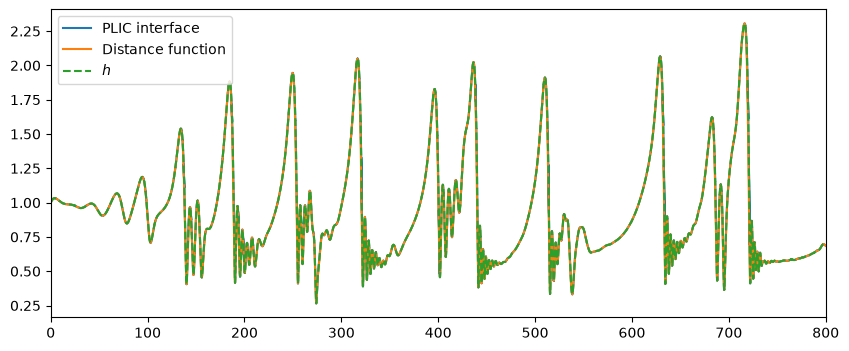

In [24]:
# Compare interface data from cell-centered height data
interface_points = np.asarray(
    interface_data["Geometry/Points"],
    dtype=float,
)
x_plic = interface_points[:, 0]
y_plic = interface_points[:, 1]

fig, ax = plt.subplots(figsize=(10, 4))
    
ax.plot(
    x_plic,
    y_plic,
    label="PLIC interface",
)

ax.plot(
    xc,
    d[0] + y[0],
    label="Distance function",
)

ax.plot(
    xc,
    h,
    "--",
    label=r"$h$",
)
ax.set_xlim(0,800)
ax.legend()
plt.show()

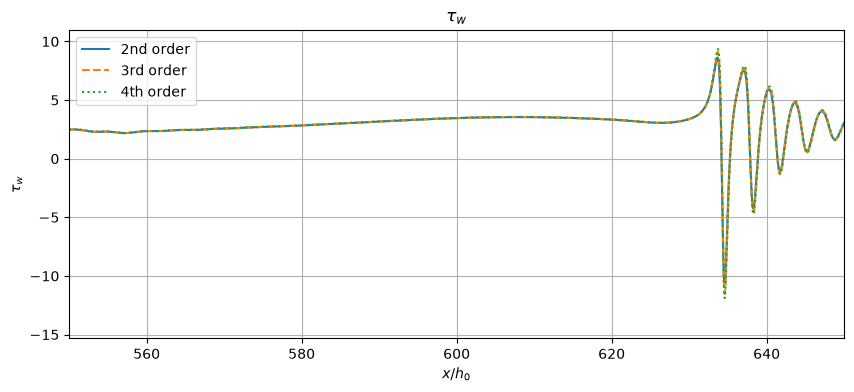

In [25]:
xlim1 = 550
xlim2 = 650
_, tau_w2 = compute_wall_shear_opt(x,y,u, mu=1.0, order=2)
_, tau_w3 = compute_wall_shear_opt(x,y,u, mu=1.0, order=3)


fig, ax = plt.subplots(figsize=(10, 4))
    
ax.plot(xc, tau_w2, label="2nd order")
ax.plot(xc, tau_w3, linestyle='--',label="3rd order")
ax.plot(xc, tau_w, linestyle=':',label="4th order")
ax.set_title(r"$\tau_w$")
ax.set_xlabel(r"$x/h_0$")
ax.set_ylabel(r"$\tau_w$")
ax.set_xlim(xlim1, xlim2)
# ax.set_ylim(-1, 5)
ax.grid(True)

ax.legend()
plt.show()

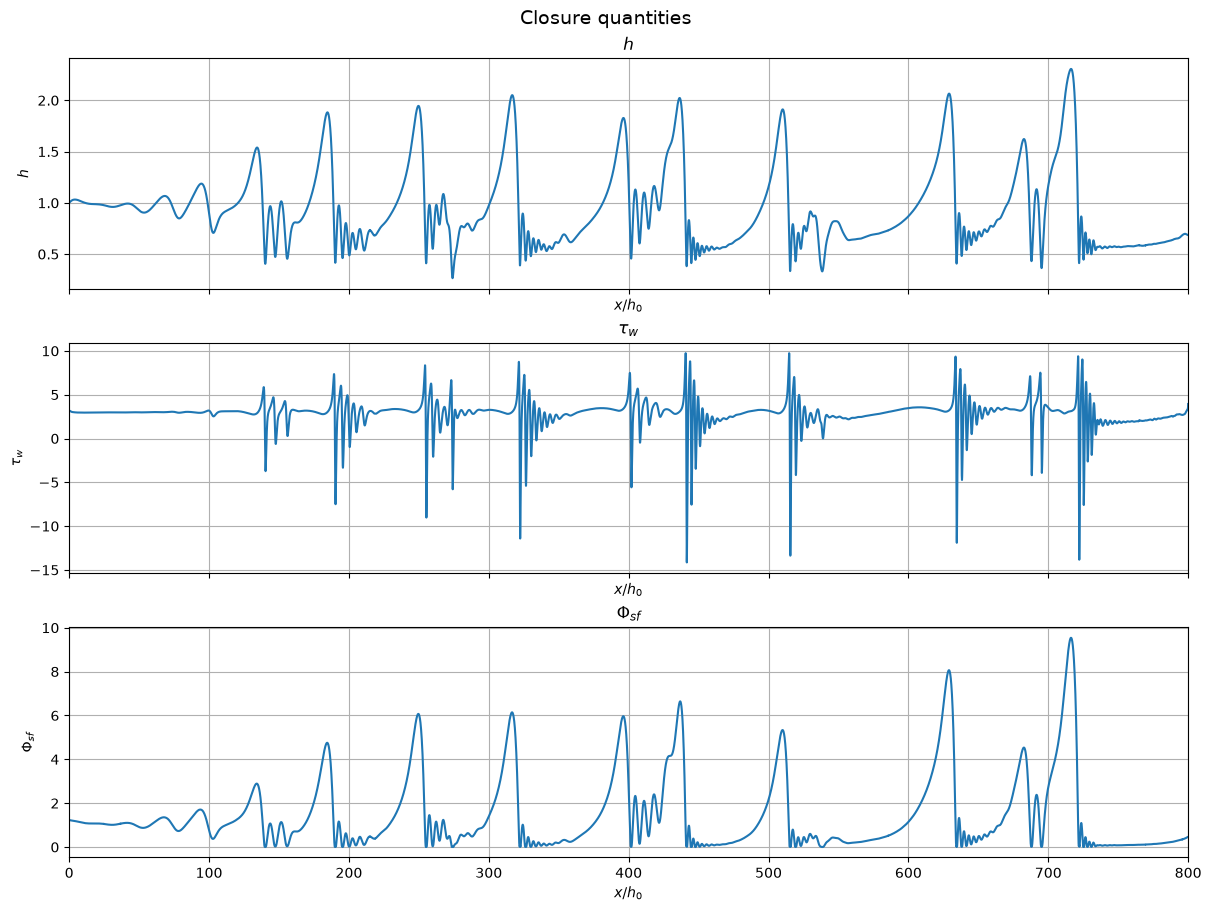

In [26]:
xlim1 = 0
xlim2 = 800
fig, ax = plt.subplots(
    3, 1,
    figsize=(12, 9),
    sharex=True,
    constrained_layout=True,
)
fig.suptitle(
    r"Closure quantities",
    fontsize=14,
)
ax[0].plot(xc, h)
ax[0].set_title(r"$h$")
ax[0].set_xlabel(r"$x/h_0$")
ax[0].set_ylabel(r"$h$")
ax[0].set_xlim(xlim1, xlim2)
ax[0].grid(True)

ax[1].plot(xc, tau_w)
ax[1].set_title(r"$\tau_w$")
ax[1].set_xlabel(r"$x/h_0$")
ax[1].set_ylabel(r"$\tau_w$")
ax[1].set_xlim(xlim1, xlim2)
# ax[1].set_ylim(-1, 6)
ax[1].grid(True)

ax[2].plot(xc, shapefactor)
ax[2].set_title(r"$\Phi_{sf}$")
ax[2].set_xlabel(r"$x/h_0$")
ax[2].set_ylabel(r"$\Phi_{sf}$")
ax[2].set_xlim(xlim1, xlim2)
# ax[2].set_ylim(0,4)
ax[2].grid(True)

plt.show()

In [27]:
# Second-order central-difference
h_x = first_derivative_x(xc, h)
h_x2 = first_derivative_x2(xc, h)
h_xx = second_derivative_x(xc, h)

q_x = first_derivative_x(xc, q)
q_xx = second_derivative_x(xc, q)

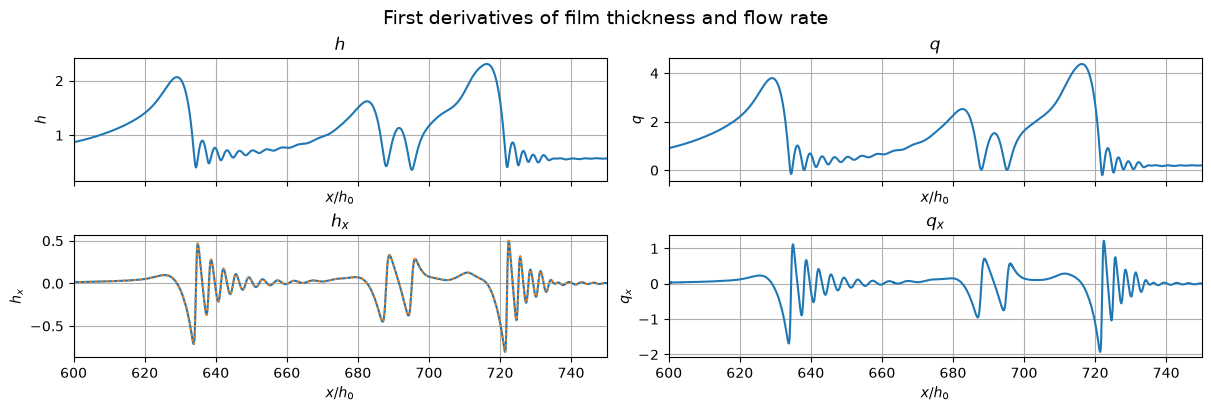

In [28]:
xlim1 = 600
xlim2 = 750
fig, ax = plt.subplots(
    2, 2,
    figsize=(12, 4),
    sharex=True,
    constrained_layout=True,
)
fig.suptitle(
    r"First derivatives of film thickness and flow rate",
    fontsize=14,
)
ax[0,0].plot(xc, h)
ax[0,0].set_title(r"$h$")
ax[0,0].set_xlabel(r"$x/h_0$")
ax[0,0].set_ylabel(r"$h$")
ax[0,0].set_xlim(xlim1, xlim2)
ax[0,0].grid(True)

ax[0,1].plot(xc, q)
ax[0,1].set_title(r"$q$")
ax[0,1].set_xlabel(r"$x/h_0$")
ax[0,1].set_ylabel(r"$q$")
ax[0,1].set_xlim(xlim1, xlim2)
ax[0,1].grid(True)

ax[1,0].plot(xc, h_x,label="4")
ax[1,0].plot(xc, h_x2,":",label="2")
ax[1,0].set_title(r"$h_x$")
ax[1,0].set_xlabel(r"$x/h_0$")
ax[1,0].set_ylabel(r"$h_x$")
ax[1,0].set_xlim(xlim1, xlim2)
ax[1,0].grid(True)

ax[1,1].plot(xc, q_x)
ax[1,1].set_title(r"$q_x$")
ax[1,1].set_xlabel(r"$x/h_0$")
ax[1,1].set_ylabel(r"$q_x$")
ax[1,1].set_xlim(xlim1, xlim2)
ax[1,1].grid(True)

plt.show()

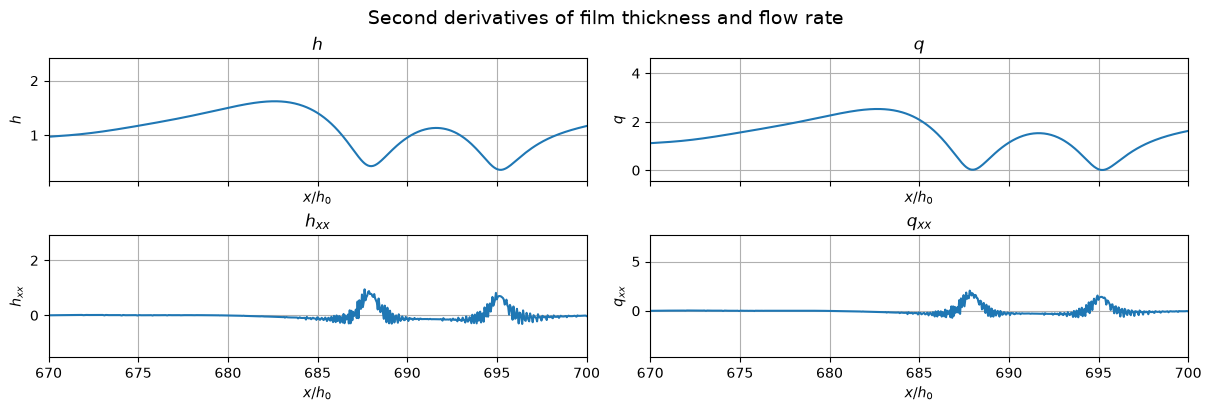

In [29]:
xlim1 = 670
xlim2 = 700
fig, ax = plt.subplots(
    2, 2,
    figsize=(12, 4),
    sharex=True,
    constrained_layout=True,
)
fig.suptitle(
    r"Second derivatives of film thickness and flow rate",
    fontsize=14,
)
ax[0,0].plot(xc, h)
ax[0,0].set_title(r"$h$")
ax[0,0].set_xlabel(r"$x/h_0$")
ax[0,0].set_ylabel(r"$h$")
ax[0,0].set_xlim(xlim1, xlim2)
ax[0,0].grid(True)

ax[0,1].plot(xc, q)
ax[0,1].set_title(r"$q$")
ax[0,1].set_xlabel(r"$x/h_0$")
ax[0,1].set_ylabel(r"$q$")
ax[0,1].set_xlim(xlim1, xlim2)
ax[0,1].grid(True)

ax[1,0].plot(xc, h_xx)
ax[1,0].set_title(r"$h_{xx}$")
ax[1,0].set_xlabel(r"$x/h_0$")
ax[1,0].set_ylabel(r"$h_{xx}$")
ax[1,0].set_xlim(xlim1, xlim2)
# ax[1,0].set_ylim(-0.2, 0.2)
ax[1,0].grid(True)

ax[1,1].plot(xc, q_xx)
ax[1,1].set_title(r"$q_{xx}$")
ax[1,1].set_xlabel(r"$x/h_0$")
ax[1,1].set_ylabel(r"$q_{xx}$")
ax[1,1].set_xlim(xlim1, xlim2)
# ax[1,1].set_ylim(-0.2, 0.2)
ax[1,1].grid(True)

plt.show()

In [30]:
# kappa_calc = h_xx / (1.0 + h_x**2)**1.5
# interface_points = np.asarray(
#         interface_data["Geometry/Points"]
#     )
# kappa_interface = np.asarray(
#         h0 * interface_data["Cells/kappa"]
#     ).squeeze()
# x_interface = interface_points[:, 0]/h0
# xc_interface = 0.5 * (x_interface[0::2] + x_interface[1::2])
# x_interface.shape
# # fig, ax = plt.subplots(figsize=(10, 4))

# # ax.plot(
# #     xc_interface,
# #     kappa_interface,
# #     label="Basilisk interface curvature",
# # )

# # ax.plot(
# #     xc,
# #     kappa_calc,
# #     "--",
# #     label=r"$h_{xx}/(1+h_x^2)^{3/2}$",
# # )

# # ax.set_xlabel(r"$x/h_0$")
# # ax.set_ylabel(r"$\kappa h_0$")
# # ax.set_title("Interface curvature comparison")
# # ax.grid(True)
# # ax.legend()

# # fig.tight_layout()
# # plt.show()

In [31]:
t = flowfield_data["Parameters/time"]
tm = flowfield_data["Parameters/time_minus"]

h_t = first_derivative_t(h,hm,t,tm)
q_t = first_derivative_t(q,qm,t,tm)

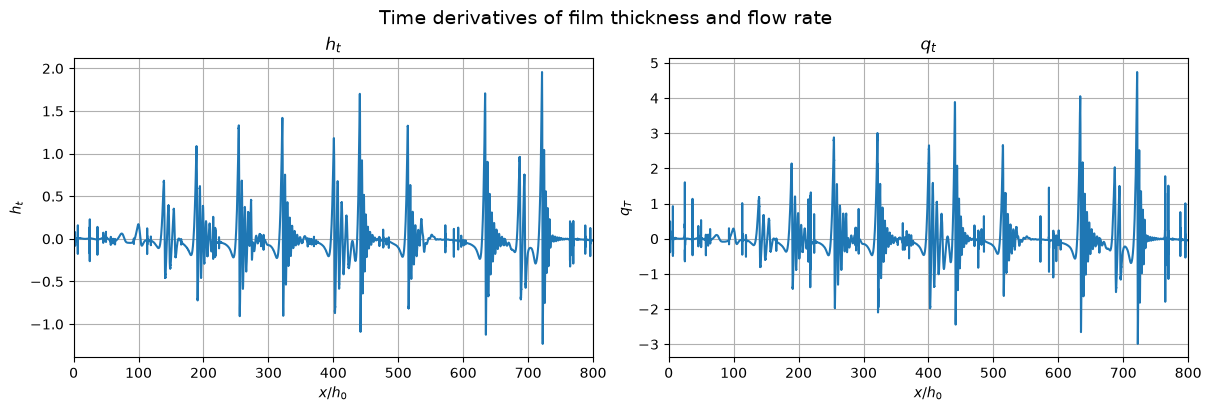

In [32]:
xlim1 = 0
xlim2 = 800
fig, ax = plt.subplots(
    1, 2,
    figsize=(12, 4),
    sharex=True,
    constrained_layout=True,
)
fig.suptitle(
    r"Time derivatives of film thickness and flow rate",
    fontsize=14,
)
ax[0].plot(xc, h_t)
ax[0].set_title(r"$h_t$")
ax[0].set_xlabel(r"$x/h_0$")
ax[0].set_ylabel(r"$h_t$")
ax[0].set_xlim(xlim1, xlim2)
ax[0].grid(True)

ax[1].plot(xc, q_t)
ax[1].set_title(r"$q_t$")
ax[1].set_xlabel(r"$x/h_0$")
ax[1].set_ylabel(r"$q_T$")
ax[1].set_xlim(xlim1, xlim2)
ax[1].grid(True)

plt.show()

The derivatives are a little noisy. We need to work on a filter or any alternate options to make it smooth and continuous.

The next section contains comparisons of the closure quantities and Lavalle's predicted values

In [33]:
## Lavalle's closure terms
Re = flowfield_data["Parameters/Re"]
beta = flowfield_data["Parameters/angle"]
Fr2 = Re*np.sin(beta)/3
Lambda = 3.0



shapefactor_lavalle = 1.2* q**2 / h
tau_w_first_order = (Re / 3.0) * Lambda**2 * h**4 * h_x
tau_w_zero_order = 3.0 * q / h**2

tau_w_lavalle = tau_w_zero_order + tau_w_first_order

R_tau = tau_w_first_order / tau_w_zero_order

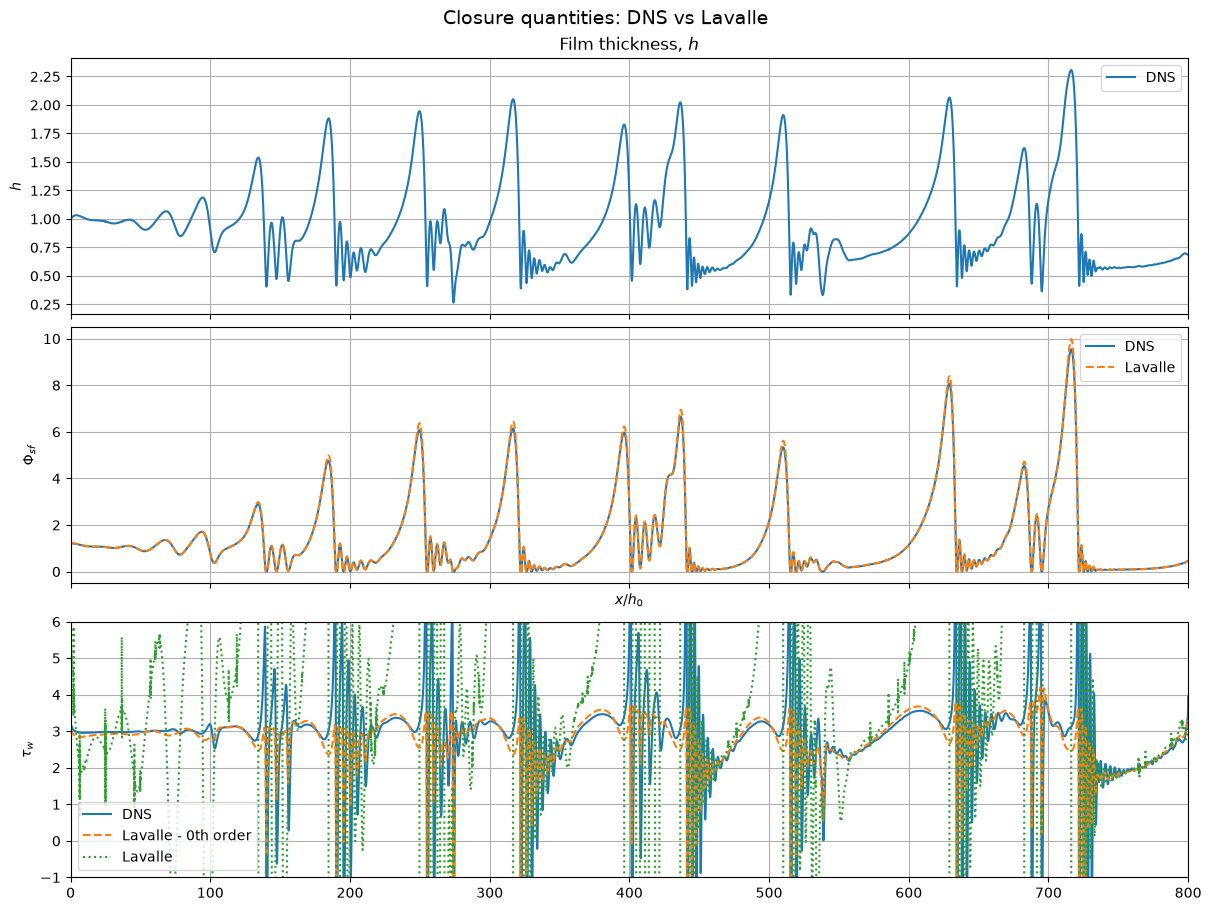

In [34]:
xlim1 = 0
xlim2 = 800
fig, ax = plt.subplots(
    3,
    1,
    figsize=(12, 9),
    sharex=True,
    constrained_layout=True,
)

fig.suptitle(
    "Closure quantities: DNS vs Lavalle",
    fontsize=14,
)

# Film thickness
ax[0].plot(
    xc,
    h,
    label="DNS",
)

ax[0].set_title(r"Film thickness, $h$")
ax[0].set_ylabel(r"$h$")
ax[0].set_xlim(xlim1, xlim2)
ax[0].grid(True)
ax[0].legend()

# Wall shear
ax[2].plot(
    xc,
    tau_w,
    label="DNS",
)

ax[2].plot(
    xc,
    tau_w_zero_order,
    "--",
    label=r"Lavalle - 0th order",
)

ax[2].plot(xc, tau_w_lavalle, ":", label=r"Lavalle")


# ax[1].set_title(rf"Wall shear, $\tau_w$ — MSE = {tau_w_mse:.3e}")
ax[2].set_ylabel(r"$\tau_w$")
ax[2].set_ylim(-1, 6)
ax[2].grid(True)
ax[2].set_xlim(xlim1, xlim2)
ax[2].legend()

# Shape factor
ax[1].plot(
    xc,
    shapefactor,
    label="DNS",
)

ax[1].plot(xc, shapefactor_lavalle, "--", label=r"Lavalle")

ax[1].set_xlabel(r"$x/h_0$")
ax[1].set_ylabel(r"$\Phi_{sf}$")
# ax[2].set_ylim(0, 4)
ax[1].grid(True)
ax[1].set_xlim(xlim1, xlim2)
ax[1].legend()

plt.show()

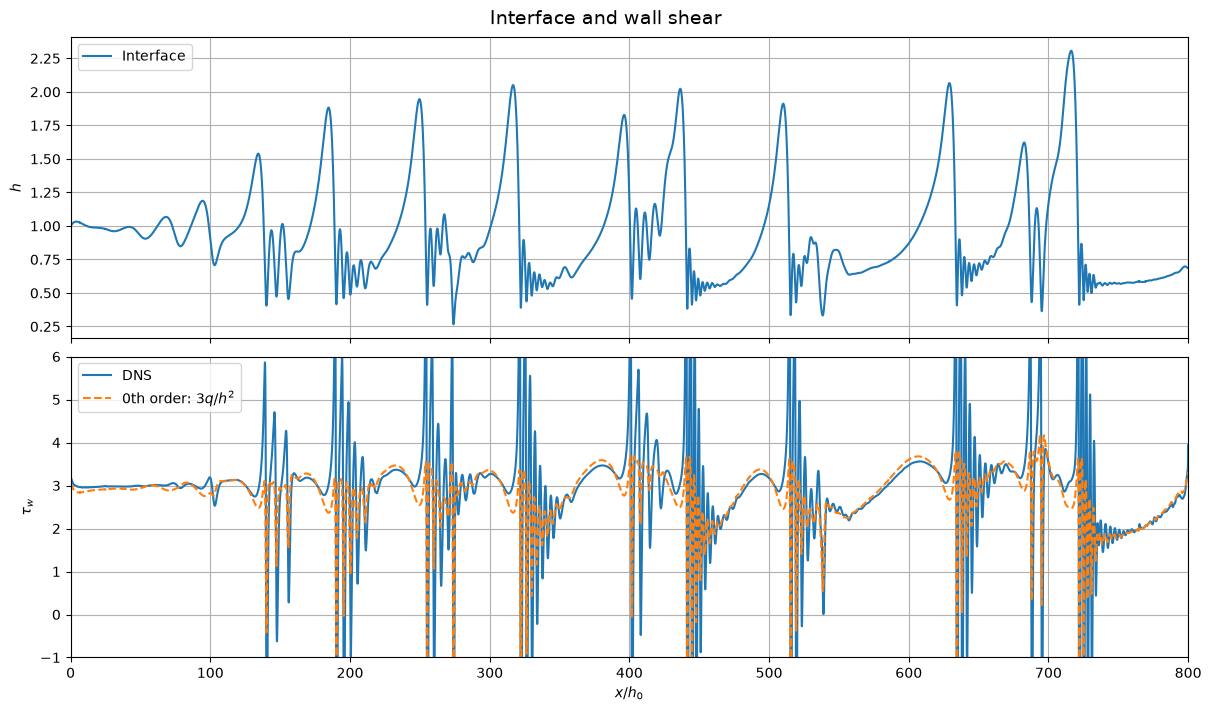

In [35]:
xlim1 = 0
xlim2 = 800

fig, ax = plt.subplots(
    2,
    1,
    figsize=(12, 7),
    sharex=True,
    constrained_layout=True,
)

fig.suptitle(
    "Interface and wall shear",
    fontsize=14,
)

# ------------------------------------------------------------
# Interface
# ------------------------------------------------------------

ax[0].plot(
    xc,
    h,
    label="Interface",
)

ax[0].set_ylabel(r"$h$")
ax[0].set_xlim(xlim1, xlim2)
ax[0].grid(True)
ax[0].legend()


# ------------------------------------------------------------
# Wall shear
# ------------------------------------------------------------

ax[1].plot(
    xc,
    tau_w,
    label="DNS",
)

ax[1].plot(
    xc,
    tau_w_zero_order,
    "--",
    label=r"0th order: $3q/h^2$",
)

ax[1].set_xlabel(r"$x/h_0$")
ax[1].set_ylabel(r"$\tau_w$")
ax[1].set_xlim(xlim1, xlim2)
ax[1].set_ylim(-1, 6)
ax[1].grid(True)
ax[1].legend()

plt.show()

In [36]:
import torch
import torch.nn as nn

class MLP(nn.Module):

    def __init__(self, input_dim=5, hidden_dim=64, output_dim=1):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, output_dim),
        )

    def forward(self, x):
        return self.network(x)

In [37]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using device: {device}")

mlp_path = Path("saved_models/MLP_Stage1_v01.pt")

mlp_checkpoint = torch.load(
    mlp_path,
    map_location=device,
    weights_only=False,
)

mlp_model = MLP(
    input_dim=5,
    hidden_dim=64,
    output_dim=1,
).to(device)

mlp_model.load_state_dict(
    mlp_checkpoint["model_state_dict"]
)

mlp_model.eval()

# Scaling information
X_mean_mlp = mlp_checkpoint["X_scaler_mean"]
X_scale_mlp = mlp_checkpoint["X_scaler_scale"]

Y_mean_mlp = mlp_checkpoint["Y_scaler_mean"][0]
Y_scale_mlp = mlp_checkpoint["Y_scaler_scale"][0]

print(f"Loaded model from epoch {mlp_checkpoint['epoch']}")
print(f"Training loss:   {mlp_checkpoint['train_loss']:.6e}")
print(f"Validation loss: {mlp_checkpoint['val_loss']:.6e}")

Using device: cpu
Loaded model from epoch 97
Training loss:   3.355080e-02
Validation loss: 3.884209e-02


In [38]:
Re_case = float(Re)

Re_array = np.full_like(h, Re_case, dtype=float)

X_mlp = np.column_stack([
    Re_array,
    h,
    q,
    h_x,
    q_x,
])

print("Input shape:", X_mlp.shape)
print("First input:", X_mlp[0])

X_mlp_scaled = (X_mlp - X_mean_mlp) / X_scale_mlp
X_mlp_tensor = torch.from_numpy(
    X_mlp_scaled.astype(np.float32)
).to(device)

mlp_model.eval()

with torch.no_grad():
    delta_tau_mlp_scaled = mlp_model(X_mlp_tensor).cpu().numpy().ravel()
    
delta_tau_mlp = delta_tau_mlp_scaled * Y_scale_mlp + Y_mean_mlp

Input shape: (16384, 5)
First input: [ 5.00000000e+01  1.00099314e+00  1.01896294e+00 -9.10675239e-04
 -2.04460354e-02]


In [39]:
tau_w_zero_order = 3.0 * q / h**2

tau_w_mlp = tau_w_zero_order + delta_tau_mlp

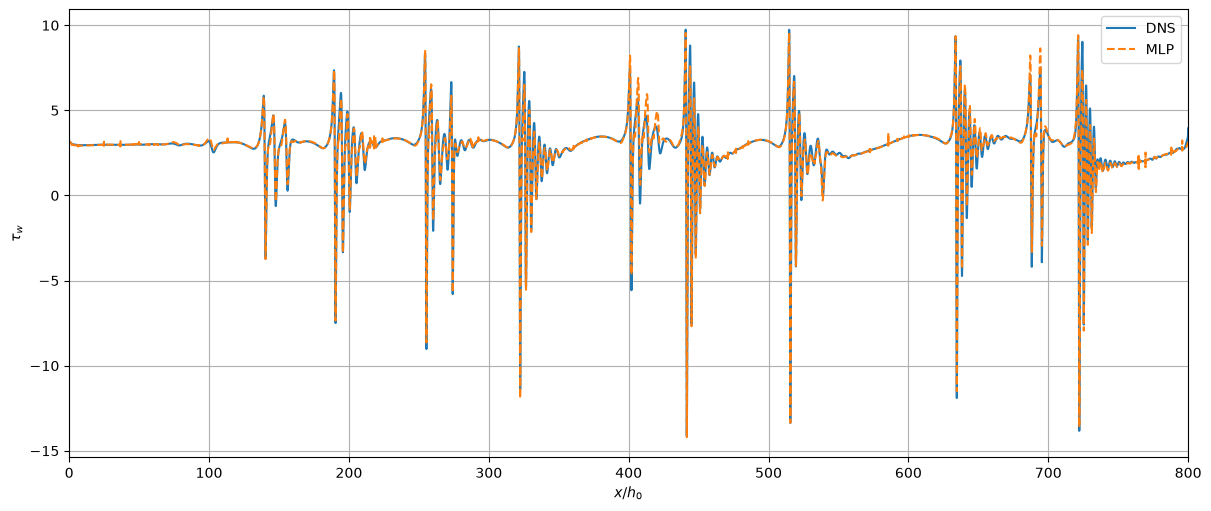

In [40]:
fig, ax = plt.subplots(figsize=(12, 5), constrained_layout=True)

ax.plot(xc, tau_w, label="DNS")
ax.plot(xc, tau_w_mlp, "--", label="MLP")
# ax.plot(xc, tau_w_zero_order, "--", label="0th order")




ax.set_xlabel(r"$x/h_0$")
ax.set_ylabel(r"$\tau_w$")
ax.set_xlim(xlim1, xlim2)
# ax.set_ylim(-1, 6)
ax.grid(True)
ax.legend()

plt.show()

In [41]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ------------------------------------------------------------
# Valid points
# ------------------------------------------------------------

valid = np.isfinite(tau_w) & np.isfinite(tau_w_zero_order) & np.isfinite(tau_w_mlp)

tau_dns_valid = tau_w[valid]
tau_zero_valid = tau_w_zero_order[valid]
tau_mlp_valid = tau_w_mlp[valid]

# ------------------------------------------------------------
# Zeroth-order errors
# ------------------------------------------------------------

mae_zero = mean_absolute_error(tau_dns_valid, tau_zero_valid)
mse_zero = mean_squared_error(tau_dns_valid, tau_zero_valid)
rmse_zero = np.sqrt(mse_zero)
r2_zero = r2_score(tau_dns_valid, tau_zero_valid)

# ------------------------------------------------------------
# MLP errors
# ------------------------------------------------------------

mae_mlp = mean_absolute_error(tau_dns_valid, tau_mlp_valid)
mse_mlp = mean_squared_error(tau_dns_valid, tau_mlp_valid)
rmse_mlp = np.sqrt(mse_mlp)
r2_mlp = r2_score(tau_dns_valid, tau_mlp_valid)

# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------

print("Wall-shear prediction")
print()
print(f"{'Model':<20} {'MAE':>12} {'RMSE':>12} {'R2':>12}")
print("-" * 60)
print(f"{'Zeroth order':<20} {mae_zero:12.6e} {rmse_zero:12.6e} {r2_zero:12.6f}")
print(f"{'MLP':<20} {mae_mlp:12.6e} {rmse_mlp:12.6e} {r2_mlp:12.6f}")

Wall-shear prediction

Model                         MAE         RMSE           R2
------------------------------------------------------------
Zeroth order         5.558261e-01 1.248780e+00     0.443653
MLP                  1.323777e-01 2.885145e-01     0.970303


In [42]:
class LocalCNN1D(nn.Module):

    def __init__(self, input_channels=3):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv1d(input_channels, 32, kernel_size=3, padding=1),
            nn.Tanh(),
            nn.Conv1d(32, 64, kernel_size=3, padding=1),
            nn.Tanh(),
            nn.Conv1d(64, 64, kernel_size=3, padding=1),
            nn.Tanh(),
        )

        self.head = nn.Sequential(
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 1),
        )

    def forward(self, x):

        x = self.conv(x)

        center = x.shape[-1] // 2

        x = x[:, :, center]

        x = self.head(x)

        return x

cnn_path = Path("saved_models/1DCNN_k4_v01.pt")

cnn_checkpoint = torch.load(
    cnn_path,
    map_location=device,
    weights_only=False,
)

cnn_model = LocalCNN1D(
    input_channels=3,
).to(device)

cnn_model.load_state_dict(
    cnn_checkpoint["model_state_dict"]
)

cnn_model.eval()

channel_mean = cnn_checkpoint["channel_mean"]
channel_std = cnn_checkpoint["channel_std"]

Y_mean_cnn = cnn_checkpoint["Y_mean"]
Y_std_cnn = cnn_checkpoint["Y_std"]

k_space = cnn_checkpoint["k_space"]
window_size = cnn_checkpoint["window_size"]

print(f"CNN loaded from epoch {cnn_checkpoint['epoch']}")
print(f"k_space = {k_space}")
print(f"window size = {window_size}")

CNN loaded from epoch 100
k_space = 4
window size = 9


In [43]:
nx = len(h)

cnn_indices = np.arange(k_space, nx - k_space)

X_cnn_list = []

for ix in cnn_indices:

    h_window = h[ix - k_space:ix + k_space + 1]
    q_window = q[ix - k_space:ix + k_space + 1]
    Re_window = np.full(window_size, Re)

    X_sample = np.stack([
        h_window,
        q_window,
        Re_window,
    ])

    X_cnn_list.append(X_sample)

X_cnn = np.asarray(X_cnn_list, dtype=np.float32)

print("CNN input shape:", X_cnn.shape)

CNN input shape: (16376, 3, 9)


In [44]:
X_cnn_scaled = (X_cnn - channel_mean[None, :, None]) / channel_std[None, :, None]

X_cnn_tensor = torch.from_numpy(
    X_cnn_scaled.astype(np.float32)
).to(device)

In [45]:
cnn_model.eval()

with torch.no_grad():
    delta_tau_cnn_scaled = cnn_model(X_cnn_tensor).cpu().numpy().ravel()

delta_tau_cnn = delta_tau_cnn_scaled * Y_std_cnn + Y_mean_cnn

In [46]:
tau_w_cnn = np.full(nx, np.nan)

tau_w_cnn[cnn_indices] = tau_w_zero_order[cnn_indices] + delta_tau_cnn

In [47]:
valid_zero = np.isfinite(tau_w) & np.isfinite(tau_w_zero_order)
valid_mlp = np.isfinite(tau_w) & np.isfinite(tau_w_mlp)
valid_cnn = np.isfinite(tau_w) & np.isfinite(tau_w_cnn)

print("Valid zeroth-order points:", np.sum(valid_zero))
print("Valid MLP points:", np.sum(valid_mlp))
print("Valid CNN points:", np.sum(valid_cnn))

mae_zero = mean_absolute_error(tau_w[valid_zero], tau_w_zero_order[valid_zero])
rmse_zero = np.sqrt(mean_squared_error(tau_w[valid_zero], tau_w_zero_order[valid_zero]))
r2_zero = r2_score(tau_w[valid_zero], tau_w_zero_order[valid_zero])

mae_mlp = mean_absolute_error(tau_w[valid_mlp], tau_w_mlp[valid_mlp])
rmse_mlp = np.sqrt(mean_squared_error(tau_w[valid_mlp], tau_w_mlp[valid_mlp]))
r2_mlp = r2_score(tau_w[valid_mlp], tau_w_mlp[valid_mlp])

mae_cnn = mean_absolute_error(tau_w[valid_cnn], tau_w_cnn[valid_cnn])
rmse_cnn = np.sqrt(mean_squared_error(tau_w[valid_cnn], tau_w_cnn[valid_cnn]))
r2_cnn = r2_score(tau_w[valid_cnn], tau_w_cnn[valid_cnn])

print()
print("Wall-shear prediction")
print()
print(f"{'Model':<20} {'MAE':>12} {'RMSE':>12} {'R2':>12}")
print("-" * 60)
print(f"{'Zeroth order':<20} {mae_zero:12.6e} {rmse_zero:12.6e} {r2_zero:12.6f}")
print(f"{'MLP':<20} {mae_mlp:12.6e} {rmse_mlp:12.6e} {r2_mlp:12.6f}")
print(f"{'1D CNN':<20} {mae_cnn:12.6e} {rmse_cnn:12.6e} {r2_cnn:12.6f}")

Valid zeroth-order points: 16384
Valid MLP points: 16384
Valid CNN points: 16376

Wall-shear prediction

Model                         MAE         RMSE           R2
------------------------------------------------------------
Zeroth order         5.558261e-01 1.248780e+00     0.443653
MLP                  1.323777e-01 2.885145e-01     0.970303
1D CNN               7.689254e-02 1.330895e-01     0.993683


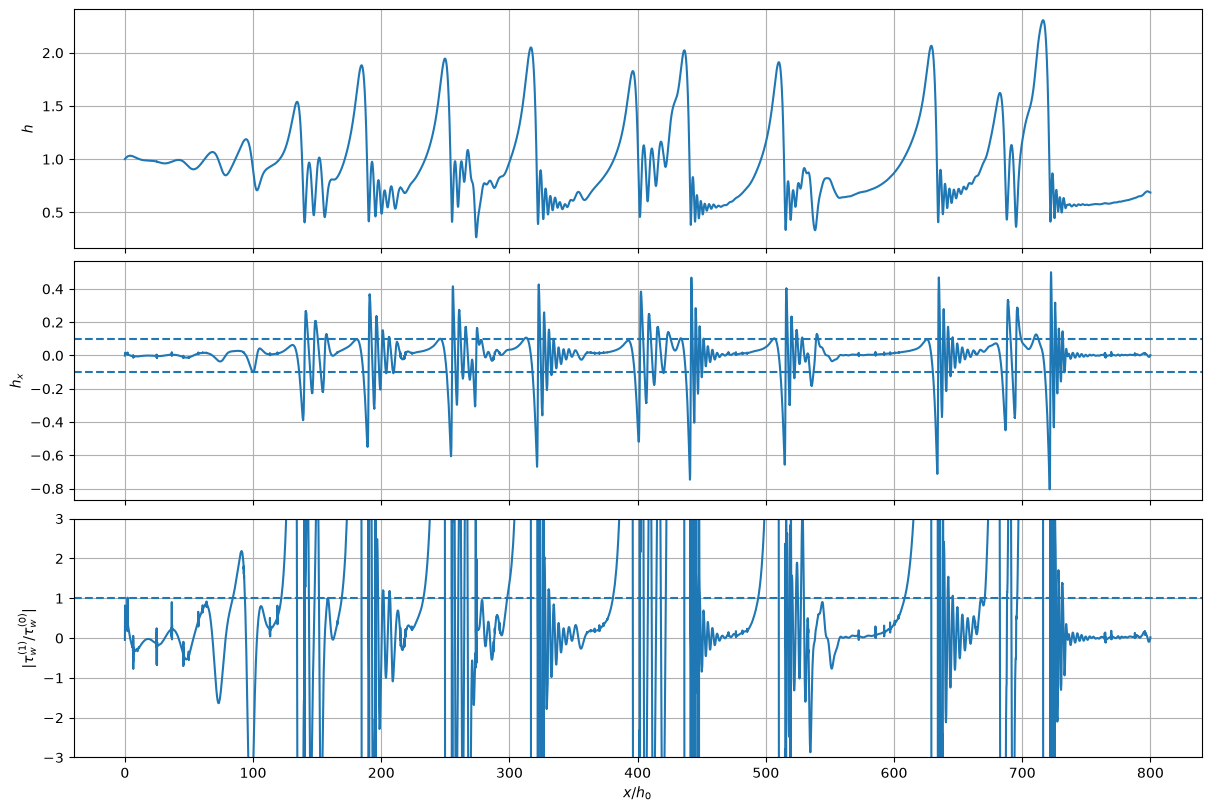

In [48]:
xlim1 = 0
xlim2 = 800
fig, ax = plt.subplots(
    3, 1,
    figsize=(12, 8),
    sharex=True,
    constrained_layout=True,
)

ax[0].plot(xc, h)
ax[0].set_ylabel(r"$h$")
ax[0].grid(True)

ax[1].plot(xc, h_x)
ax[1].axhline(0.1, linestyle="--")
ax[1].axhline(-0.1, linestyle="--")
ax[1].set_ylabel(r"$h_x$")
ax[1].grid(True)

ax[2].plot(xc, R_tau)
ax[2].axhline(1.0, linestyle="--")
ax[2].set_ylabel(
    r"$|\tau_w^{(1)}/\tau_w^{(0)}|$"
)
ax[2].set_xlabel(r"$x/h_0$")
# ax[2].set_yscale("log")
ax[2].set_ylim(-3, 3)
ax[2].grid(True)

plt.show()

Other closure variables from the no-assumption thin film formulation

In [49]:
def compute_interface_velocity(u, y, h):
    """
    Compute streamwise velocity u(x, h(x)) at the interface
    by linear interpolation in the y-direction.

    Parameters
    ----------
    u : ndarray, shape (ny, nx)
        Cell-centered streamwise velocity.

    y : ndarray, shape (ny,nx)
        Cell-center y coordinates.

    h : ndarray, shape (nx,)
        Interface height at each x location.

    Returns
    -------
    u_interface : ndarray, shape (nx,)
        Streamwise velocity evaluated at y = h(x).
    """

    u = np.asarray(u)
    y = np.asarray(y)
    h = np.asarray(h)
    
    y = y[:,0]
    ny, nx = u.shape

    if y.size != ny:
        raise ValueError(
            f"y has {y.size} points but u has {ny} y-columns."
        )

    if h.size != nx:
        raise ValueError(
            f"h has {h.size} points but u has {nx} x-rows."
        )

    u_interface = np.empty(nx)

    for i in range(nx):
        u_interface[i] = np.interp(h[i], y, u[:, i])

    return u_interface

In [50]:
Phi_i = compute_interface_velocity(u, y, h)

Phi_i_lavalle_zero = Lambda * h**2 / 2
Phi_i_lavalle_one = Re/24 * h * (-h**2 + 2* h**2 + 4* h**2) * h * ((Lambda * h) * Lambda * h_x)
Phi_i_lavalle = Phi_i_lavalle_zero + Phi_i_lavalle_one

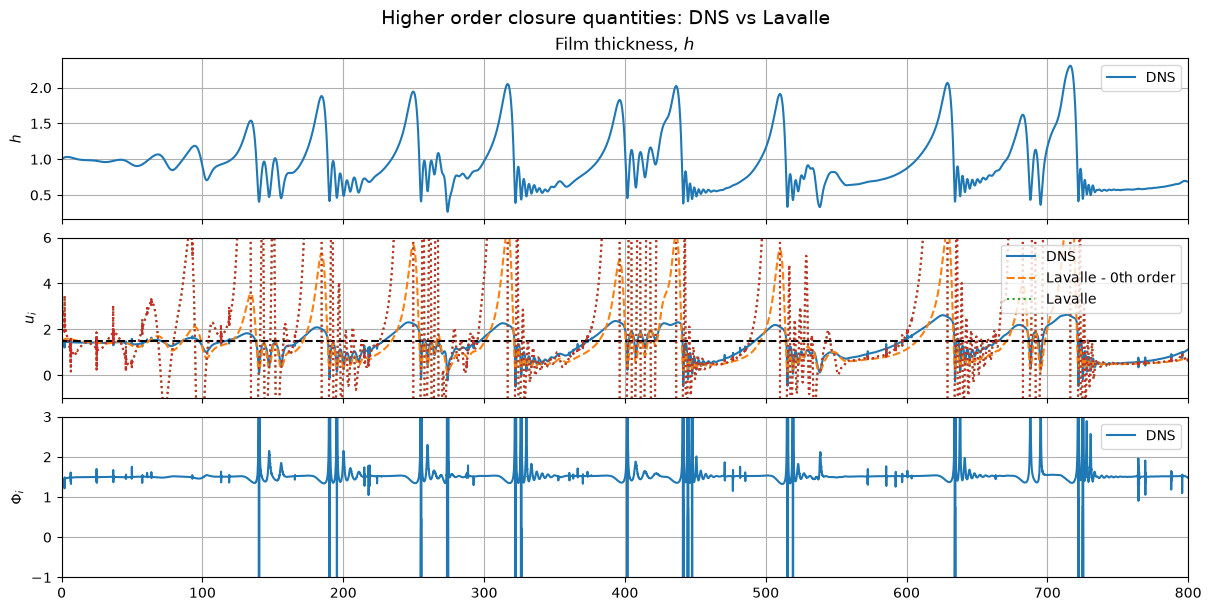

In [51]:
xlim1 = 0
xlim2 = 800
fig, ax = plt.subplots(
    3,
    1,
    figsize=(12, 6),
    sharex=True,
    constrained_layout=True,
)

fig.suptitle(
    "Higher order closure quantities: DNS vs Lavalle",
    fontsize=14,
)

# Film thickness
ax[0].plot(
    xc,
    h,
    label="DNS",
)

ax[0].set_title(r"Film thickness, $h$")
ax[0].set_ylabel(r"$h$")
ax[0].set_xlim(xlim1, xlim2)
ax[0].grid(True)
ax[0].legend()

# Velocity at interface
ax[1].plot(
    xc,
    Phi_i,
    label="DNS",
)

ax[1].plot(
    xc,
    Phi_i_lavalle_zero,
    "--",
    label=r"Lavalle - 0th order",
)

ax[1].plot(
    xc,
    Phi_i_lavalle,
    ":",
    label=r"Lavalle",
)


# ax[1].set_title(rf"Wall shear, $\tau_w$ — MSE = {tau_w_mse:.3e}")
ax[1].set_ylabel(r"$u_i$")
ax[1].axhline(1.5, linestyle="--",color="black")
ax[1].set_ylim(-1, 6)
ax[1].grid(True)
ax[1].set_xlim(xlim1, xlim2)
ax[1].legend()


ax[2].plot(
    xc,
    h * Phi_i / q,
    label="DNS",
)
ax[1].plot(
    xc,
    Phi_i_lavalle,
    ":",
    label=r"Lavalle",
)


# ax[1].set_title(rf"Wall shear, $\tau_w$ — MSE = {tau_w_mse:.3e}")
ax[2].set_ylabel(r"$\Phi_i$")
ax[2].set_ylim(-1, 3)
ax[2].grid(True)
ax[2].set_xlim(xlim1, xlim2)
ax[2].legend()


plt.show()

In [52]:
## A_0 and A_1


Pressure profile

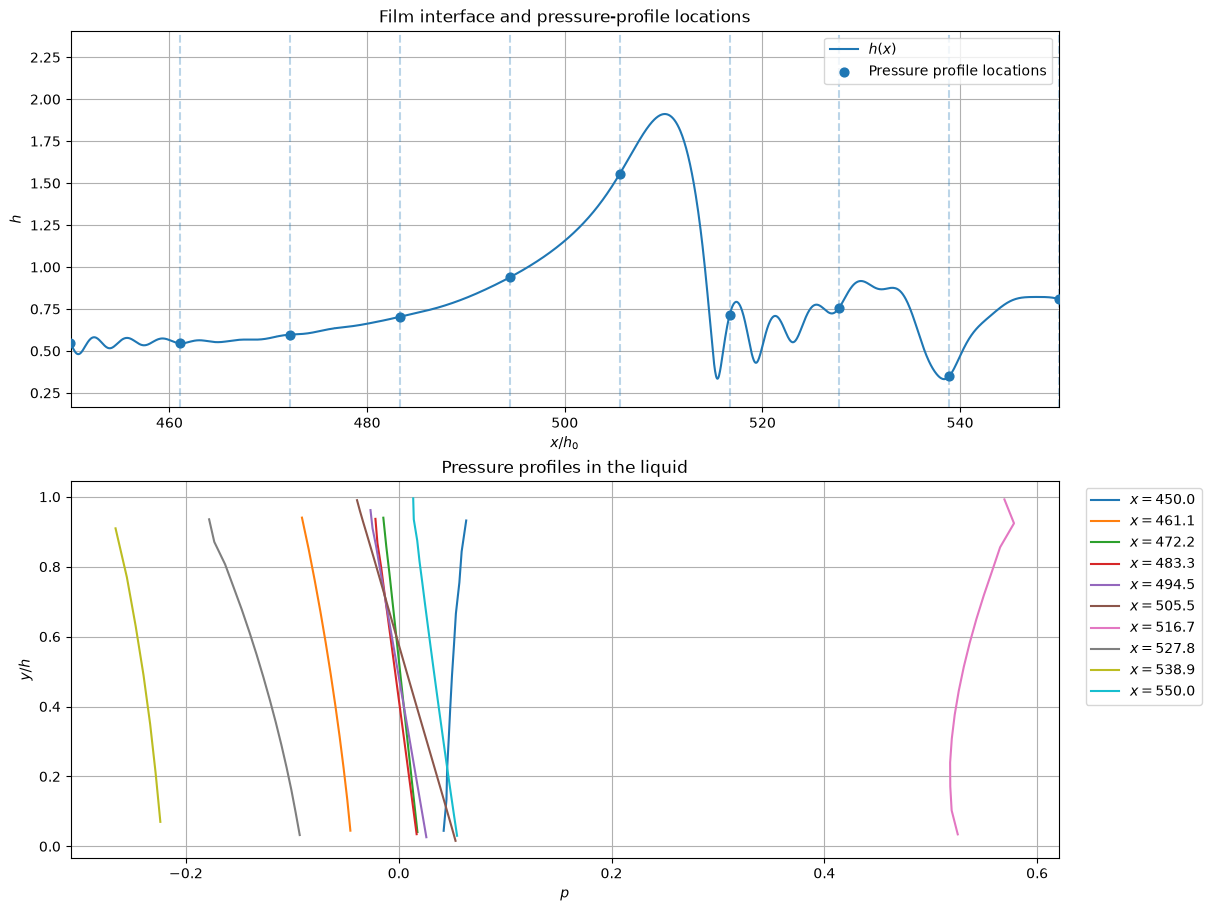

In [53]:
xlim1 = 450
xlim2 = 550
n_profiles = 10

# Target x locations
x_targets = np.linspace(xlim1, xlim2, n_profiles,)

# 1D x coordinate for the Cartesian grid
x_1d = x[0, :]

# Find nearest grid column to each target x
x_indices = np.array([
    np.argmin(np.abs(x_1d - x_target))
    for x_target in x_targets
])

x_selected = x_1d[x_indices]

fig, ax = plt.subplots(
    2, 1,
    figsize=(12, 9),
    constrained_layout=True,
)

ax[0].plot(
    x_1d,
    h,
    linewidth=1.5,
    label=r"$h(x)$",
)


ax[0].scatter(
    x_selected,
    h[x_indices],
    s=40,
    zorder=3,
    label="Pressure profile locations",
)

for xi in x_selected:
    ax[0].axvline(
        xi,
        linestyle="--",
        alpha=0.3,
    )

ax[0].set_xlim(xlim1, xlim2)
ax[0].set_xlabel(r"$x/h_0$")
ax[0].set_ylabel(r"$h$")
ax[0].set_title("Film interface and pressure-profile locations")
ax[0].grid(True)
ax[0].legend()

for i in x_indices:

    h_i = h[i]

    y_profile = y[:, i]
    p_profile = p[:, i]

    # Retain only liquid region
    liquid_mask = y_profile <= h_i

    ax[1].plot(
        p_profile[liquid_mask],
        y_profile[liquid_mask]/h_i,
        label=fr"$x={x_1d[i]:.1f}$",
    )

ax[1].set_xlabel(r"$p$")
ax[1].set_ylabel(r"$y/h$")
ax[1].set_title("Pressure profiles in the liquid")
ax[1].grid(True)

ax[1].legend(bbox_to_anchor=(1.02, 1), loc="upper left",)

plt.show()

In [54]:
# ------------------------------------------------------------
# Test hydrostatic pressure assumption at every x-location
# ------------------------------------------------------------

x_1d = x[0, :]
nx = len(x_1d)

r2_values = np.full(nx, np.nan)
rmse_values = np.full(nx, np.nan)
slope_values = np.full(nx, np.nan)

r2_threshold = 0.95

In [55]:
for i in range(nx):

    y_profile = y[:, i]
    p_profile = p[:, i]
    h_i = h[i]

    liquid_mask = y_profile <= h_i

    y_liquid = y_profile[liquid_mask]
    p_liquid = p_profile[liquid_mask]

    finite_mask = np.isfinite(y_liquid) & np.isfinite(p_liquid)

    y_liquid = y_liquid[finite_mask]
    p_liquid = p_liquid[finite_mask]

    if len(y_liquid) < 3:
        continue

    coefficients = np.polyfit(y_liquid, p_liquid, 1)

    slope = coefficients[0]
    intercept = coefficients[1]

    p_fit = slope * y_liquid + intercept

    residual = p_liquid - p_fit

    ss_res = np.sum(residual**2)
    ss_tot = np.sum((p_liquid - np.mean(p_liquid))**2)

    if ss_tot > 0.0:
        r2_values[i] = 1.0 - ss_res / ss_tot

    rmse_values[i] = np.sqrt(np.mean(residual**2))
    slope_values[i] = slope

# ------------------------------------------------------------
# Identify non-linear pressure profiles
# ------------------------------------------------------------

valid_profiles = np.isfinite(r2_values)

nonlinear_profiles = valid_profiles & (r2_values < r2_threshold)

n_valid = np.sum(valid_profiles)
n_nonlinear = np.sum(nonlinear_profiles)

fraction_nonlinear = n_nonlinear / n_valid

print(f"Valid pressure profiles: {n_valid}")
print(f"Profiles with R^2 < {r2_threshold}: {n_nonlinear}")
print(f"Fraction non-linear: {fraction_nonlinear:.4f}")
print(f"Percentage non-linear: {100.0 * fraction_nonlinear:.2f}%")

Valid pressure profiles: 16384
Profiles with R^2 < 0.95: 3350
Fraction non-linear: 0.2045
Percentage non-linear: 20.45%


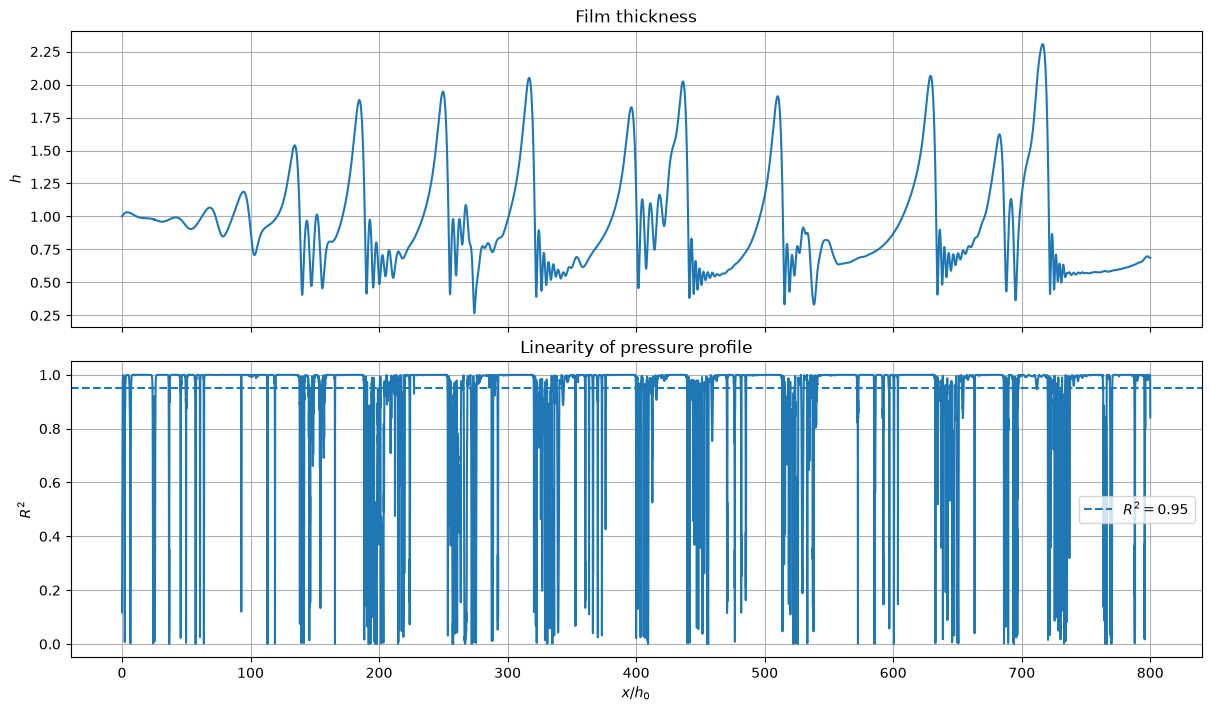

In [56]:
fig, ax = plt.subplots(2, 1, figsize=(12, 7), sharex=True, constrained_layout=True)

ax[0].plot(x_1d, h)
ax[0].set_ylabel(r"$h$")
ax[0].set_title("Film thickness")
ax[0].grid(True)

ax[1].plot(x_1d, r2_values)
ax[1].axhline(r2_threshold, linestyle="--", label=fr"$R^2={r2_threshold}$")
ax[1].set_xlabel(r"$x/h_0$")
ax[1].set_ylabel(r"$R^2$")
ax[1].set_title("Linearity of pressure profile")
ax[1].grid(True)
ax[1].legend()

plt.show()

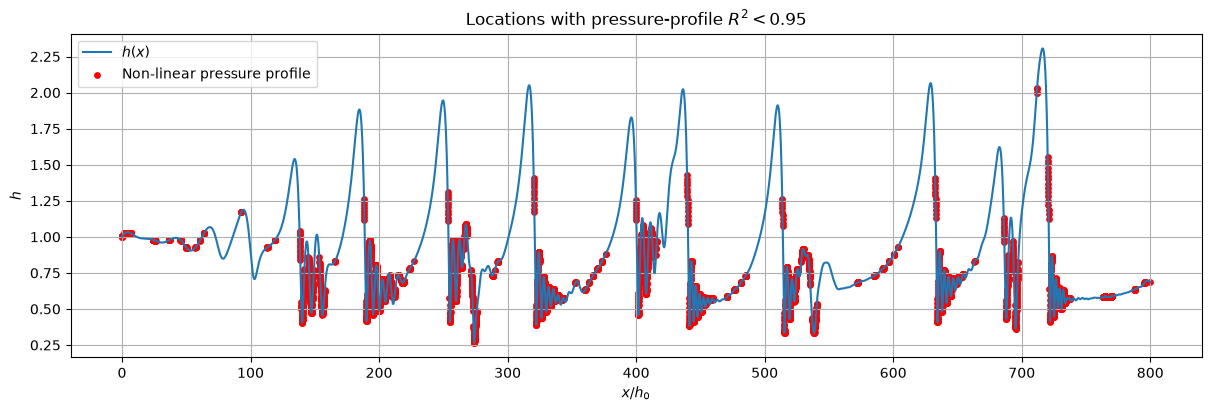

In [57]:
fig, ax = plt.subplots(figsize=(12, 4), constrained_layout=True)

ax.plot(x_1d, h, label=r"$h(x)$")

ax.scatter(x_1d[nonlinear_profiles], h[nonlinear_profiles], s=15, label="Non-linear pressure profile", color="red")

ax.set_xlabel(r"$x/h_0$")
ax.set_ylabel(r"$h$")
ax.set_title(fr"Locations with pressure-profile $R^2 < {r2_threshold}$")
ax.grid(True)
ax.legend()

plt.show()

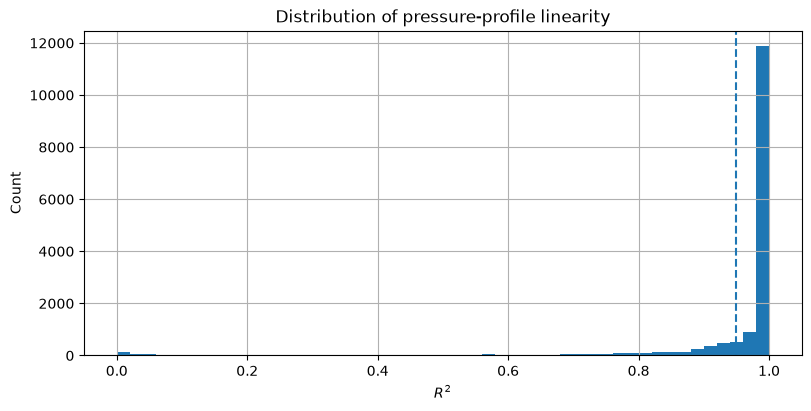

In [58]:
fig, ax = plt.subplots(figsize=(8, 4), constrained_layout=True)

ax.hist(r2_values[valid_profiles], bins=50)

ax.axvline(r2_threshold, linestyle="--")

ax.set_xlabel(r"$R^2$")
ax.set_ylabel("Count")
ax.set_title("Distribution of pressure-profile linearity")
ax.grid(True)

plt.show()

Force balance analysis

Correlations between closure terms and physical variables. 

In [59]:
from scipy.stats import pearsonr, spearmanr
import pandas as pd

physical_variables = {
    "h": h,
    "h_x": h_x,
    "h_xx": h_xx,
    "h_t": h_t,
    "q": q,
    "q_x": q_x,
    "q_xx": q_xx,
    "q_t": q_t,
}

closure_variables = {
    "tau_w": tau_w,
    "shapefactor": shapefactor,
    "u_interface": Phi_i,
}

# ------------------------------------------------------------
# Compute Pearson and Spearman correlations
# ------------------------------------------------------------

pearson_corr = np.zeros(
    (len(closure_variables), len(physical_variables))
)

spearman_corr = np.zeros_like(pearson_corr)

for i, (closure_name, closure_data) in enumerate(
    closure_variables.items()
):
    for j, (physical_name, physical_data) in enumerate(
        physical_variables.items()
    ):

        a = np.asarray(closure_data).ravel()
        b = np.asarray(physical_data).ravel()

        if a.size != b.size:
            raise ValueError(
                f"{closure_name} and {physical_name} "
                f"have different sizes: {a.size} vs {b.size}"
            )

        # Keep only finite pairs
        mask = (
            np.isfinite(a)
            & np.isfinite(b)
        )

        a_valid = a[mask]
        b_valid = b[mask]

        pearson_corr[i, j] = pearsonr(
            a_valid,
            b_valid,
        ).statistic

        spearman_corr[i, j] = spearmanr(
            a_valid,
            b_valid,
        ).statistic

# ------------------------------------------------------------
# Put results in DataFrames
# ------------------------------------------------------------

pearson_df = pd.DataFrame(
    pearson_corr,
    index=closure_variables.keys(),
    columns=physical_variables.keys(),
)

spearman_df = pd.DataFrame(
    spearman_corr,
    index=closure_variables.keys(),
    columns=physical_variables.keys(),
)

print("Pearson correlation")
display(pearson_df)

print("\nSpearman correlation")
display(spearman_df)


Pearson correlation


,h,h_x,h_xx,h_t,q,q_x,q_xx,q_t
tau_w,0.288215,-0.558971,-0.576261,0.561985,0.285492,-0.557238,-0.569381,0.552366
shapefactor,0.965963,0.001160,-0.162556,-0.003375,0.989352,0.004468,-0.159347,-0.005106
u_interface,0.904989,-0.016033,-0.307017,0.019797,0.905937,-0.017110,-0.300560,0.022835



Spearman correlation


,h,h_x,h_xx,h_t,q,q_x,q_xx,q_t
tau_w,0.535168,-0.197562,-0.320055,0.192361,0.589732,-0.187315,-0.323432,0.188807
shapefactor,0.984471,0.231865,-0.235086,-0.237037,0.998800,0.240846,-0.231235,-0.234675
u_interface,0.959362,0.253083,-0.196056,-0.260250,0.983543,0.264744,-0.196228,-0.255922


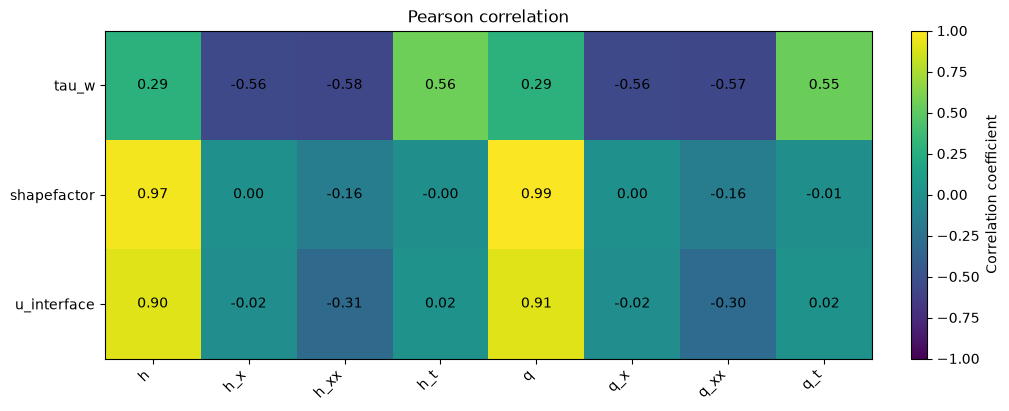

In [60]:
fig, ax = plt.subplots(
    figsize=(10, 4),
    constrained_layout=True,
)

im = ax.imshow(
    pearson_df.values,
    vmin=-1,
    vmax=1,
    aspect="auto",
)

ax.set_xticks(
    np.arange(len(physical_variables))
)

ax.set_xticklabels(
    physical_variables.keys(),
    rotation=45,
    ha="right",
)

ax.set_yticks(
    np.arange(len(closure_variables))
)

ax.set_yticklabels(
    closure_variables.keys()
)

ax.set_title("Pearson correlation")

# Write correlation values inside cells
for i in range(pearson_df.shape[0]):
    for j in range(pearson_df.shape[1]):
        ax.text(
            j,
            i,
            f"{pearson_df.iloc[i, j]:.2f}",
            ha="center",
            va="center",
        )

fig.colorbar(
    im,
    ax=ax,
    label="Correlation coefficient",
)

plt.show()

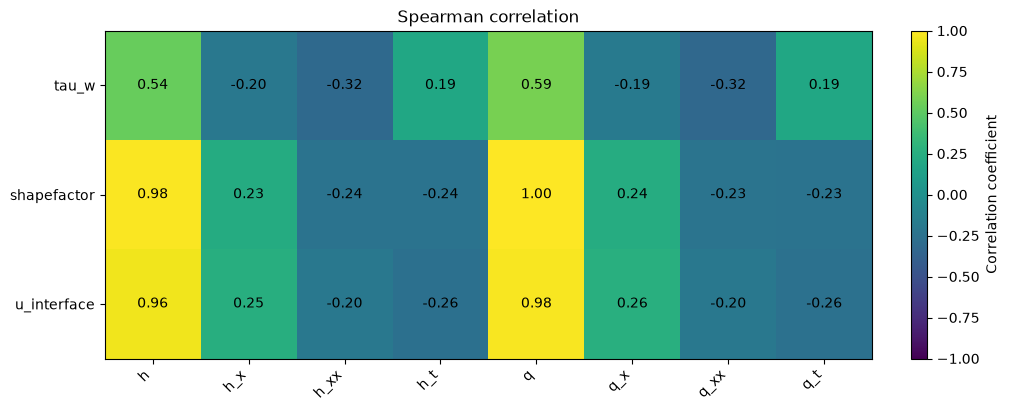

In [61]:
fig, ax = plt.subplots(
    figsize=(10, 4),
    constrained_layout=True,
)

im = ax.imshow(
    spearman_df.values,
    vmin=-1,
    vmax=1,
    aspect="auto",
)

ax.set_xticks(
    np.arange(len(physical_variables))
)

ax.set_xticklabels(
    physical_variables.keys(),
    rotation=45,
    ha="right",
)

ax.set_yticks(
    np.arange(len(closure_variables))
)

ax.set_yticklabels(
    closure_variables.keys()
)

ax.set_title("Spearman correlation")

for i in range(spearman_df.shape[0]):
    for j in range(spearman_df.shape[1]):
        ax.text(
            j,
            i,
            f"{spearman_df.iloc[i, j]:.2f}",
            ha="center",
            va="center",
        )

fig.colorbar(
    im,
    ax=ax,
    label="Correlation coefficient",
)

plt.show()

Interface against inlet noise - Dr. Bala

In [62]:
case_dir_signal = Path("/blue/bala1s/krishnap.kalivel/TLFHydrodynamics/thinfilm-closure-ml/datasets/BasC/param_space/whitenoise_check")
signal_file = case_dir_signal / "inlet_signal.dat"

signal = np.loadtxt(
    signal_file,
    comments="#",
)

t_signal = signal[:, 0]
inlet_F = signal[:, 1]
inlet_U = signal[:, 2]
inlet_U_dim = signal[:, 3]

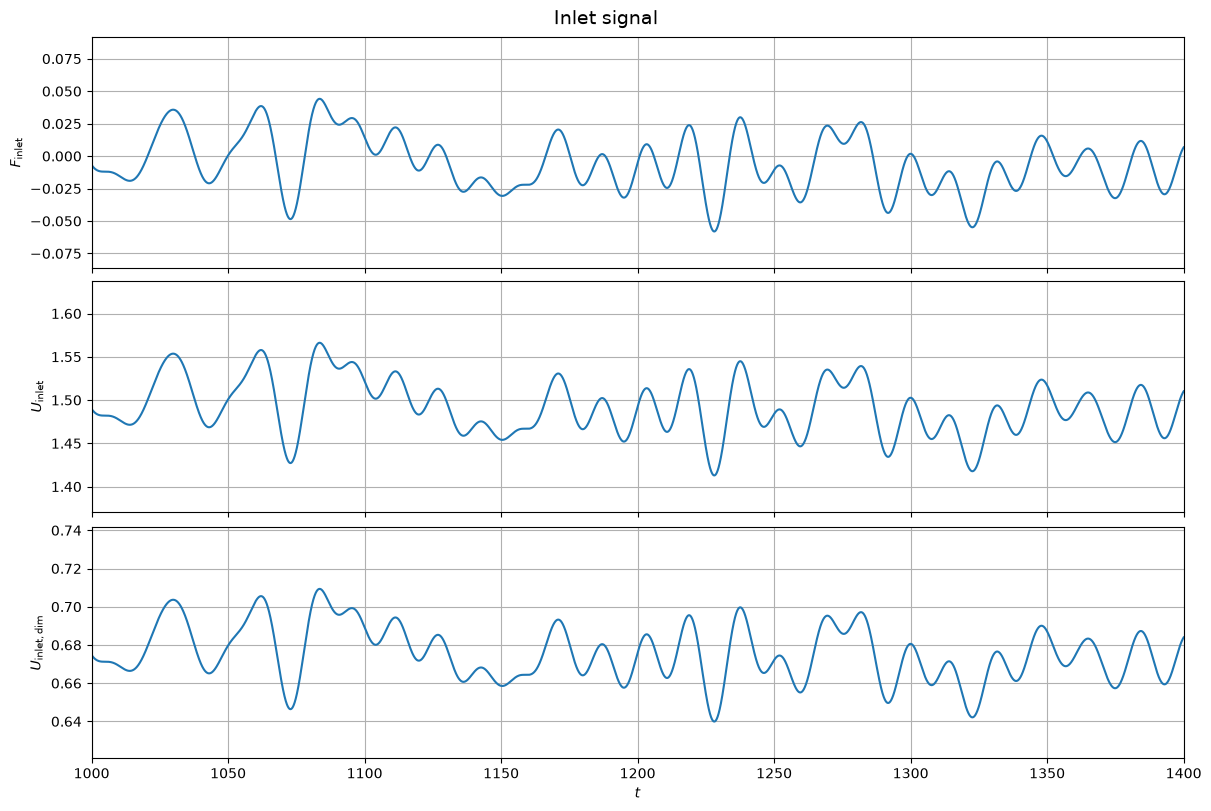

In [63]:
xlim1 = 1000
xlim2 = 1400


fig, ax = plt.subplots(
    3, 1,
    figsize=(12, 8),
    sharex=True,
    constrained_layout=True,
)

fig.suptitle(
    "Inlet signal",
    fontsize=14,
)

# Inlet F
ax[0].plot(
    t_signal,
    inlet_F,
)

ax[0].set_ylabel(r"$F_{\mathrm{inlet}}$")
ax[0].grid(True)
ax[0].set_xlim(xlim1, xlim2)
# Nondimensional inlet velocity
ax[1].plot(
    t_signal,
    inlet_U,
)

ax[1].set_ylabel(r"$U_{\mathrm{inlet}}$")
ax[1].grid(True)
ax[1].set_xlim(xlim1, xlim2)
# Dimensional inlet velocity
ax[2].plot(
    t_signal,
    inlet_U_dim,
)

ax[2].set_xlabel(r"$t$")
ax[2].set_ylabel(
    r"$U_{\mathrm{inlet,dim}}$"
)
ax[2].grid(True)
ax[2].set_xlim(xlim1, xlim2)
plt.show()